<a href="https://colab.research.google.com/github/athstack/machine-learning/blob/main/student_performance_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Student Performance Prediction using Recurrent Neural Networks: A Comparative Study of SimpleRNN, LSTM, and GRU Models

In [1]:
# ============================================================
# EDUCATION DEEP LEARNING PROJECT
# SIMPLE RNN vs LSTM vs GRU
# UCI STUDENT PERFORMANCE DATASET
# ============================================================

# ============================================================
# 1. INSTALL REQUIRED PACKAGES
# ============================================================

!pip -q install wget

# ============================================================
# 2. IMPORT LIBRARIES
# ============================================================

import os
import glob
import zipfile
import shutil
import time
import random
import warnings

import wget
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    explained_variance_score
)

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    SimpleRNN,
    LSTM,
    GRU,
    Dense,
    Dropout
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

warnings.filterwarnings("ignore")

  Preparing metadata (setup.py) ... done


In [2]:
# ============================================================
# 3. RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("Random seed:", SEED)

# ============================================================
# 4. DOWNLOAD DATASET
# ============================================================

DATA_DIR = "/content/student_performance"
os.makedirs(DATA_DIR, exist_ok=True)

ZIP_PATH = "/content/student.zip"

DATA_URL = (
    "https://archive.ics.uci.edu/static/public/320/"
    "student+performance.zip"
)

if not os.path.exists(ZIP_PATH):

    print("\nDownloading UCI Student Performance dataset...")

    wget.download(DATA_URL, ZIP_PATH)

    print("\nDataset downloaded successfully.")

else:

    print("\nDataset ZIP already exists.")
    print("Using:", ZIP_PATH)


TensorFlow version: 2.20.0
Random seed: 42


Dataset downloaded successfully.


In [3]:
# ============================================================
# 5. EXTRACT DATASET
# ============================================================

print("\nExtracting dataset...")

try:

    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)

    print("Main ZIP extracted successfully.")

except zipfile.BadZipFile:

    raise RuntimeError(
        "The downloaded file is not a valid ZIP file."
    )


Extracting dataset...
Main ZIP extracted successfully.


In [4]:
# ============================================================
# 6. FIND ALL FILES
# ============================================================

print("\nFiles found after first extraction:")

for root, dirs, files in os.walk(DATA_DIR):

    for file in files:

        print(
            os.path.relpath(
                os.path.join(root, file),
                DATA_DIR
            )
        )


Files found after first extraction:
.student.zip_old
student.zip


In [5]:
# ============================================================
# 7. EXTRACT NESTED ZIP FILES
# ============================================================

nested_zip_files = glob.glob(
    os.path.join(
        DATA_DIR,
        "**",
        "*.zip"
    ),
    recursive=True
)

for nested_zip in nested_zip_files:

    try:

        nested_folder = (
            os.path.splitext(nested_zip)[0]
            + "_extracted"
        )

        if not os.path.exists(nested_folder):

            os.makedirs(
                nested_folder,
                exist_ok=True
            )

            print(
                "\nExtracting nested ZIP:",
                nested_zip
            )

            with zipfile.ZipFile(
                nested_zip,
                "r"
            ) as zip_ref:

                zip_ref.extractall(
                    nested_folder
                )

    except zipfile.BadZipFile:

        print(
            "Skipping invalid ZIP:",
            nested_zip
        )


Extracting nested ZIP: /content/student_performance/student.zip


In [6]:
# ============================================================
# 8. SEARCH FOR student-mat.csv
# ============================================================

print("\nSearching for student-mat.csv...")

math_files = glob.glob(
    os.path.join(
        DATA_DIR,
        "**",
        "student-mat.csv"
    ),
    recursive=True
)

# Also search for case variations
if len(math_files) == 0:

    all_files = glob.glob(
        os.path.join(
            DATA_DIR,
            "**",
            "*"
        ),
        recursive=True
    )

    for file in all_files:

        if os.path.basename(file).lower() == "student-mat.csv":

            math_files.append(file)


Searching for student-mat.csv...


In [7]:
# ============================================================
# 9. IF NOT FOUND, SEARCH EVERYTHING
# ============================================================

if len(math_files) == 0:

    print("\nstudent-mat.csv was NOT found.")

    print("\nAll files currently available:")

    for root, dirs, files in os.walk(DATA_DIR):

        for file in files:

            print(
                os.path.join(
                    root,
                    file
                )
            )

    raise FileNotFoundError(
        "\nCould not locate student-mat.csv."
    )

In [8]:
# ============================================================
# 10. GET DATASET PATH
# ============================================================

math_path = math_files[0]

print("\nDataset found successfully:")
print(math_path)


Dataset found successfully:
/content/student_performance/student_extracted/student-mat.csv


In [9]:
# ============================================================
# 11. LOAD DATASET
# ============================================================

df = pd.read_csv(
    math_path,
    sep=";"
)

print("\nDataset loaded successfully.")

print("\nDataset shape:")
print(df.shape)

print("\nFirst 5 rows:")
display(df.head())


Dataset loaded successfully.

Dataset shape:
(395, 33)

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [10]:
# ============================================================
# 12. DISPLAY ALL COLUMNS
# ============================================================

print("\nAll dataset columns:")

for i, column in enumerate(df.columns, start=1):

    print(
        f"{i:02d}. {column}"
    )


All dataset columns:
01. school
02. sex
03. age
04. address
05. famsize
06. Pstatus
07. Medu
08. Fedu
09. Mjob
10. Fjob
11. reason
12. guardian
13. traveltime
14. studytime
15. failures
16. schoolsup
17. famsup
18. paid
19. activities
20. nursery
21. higher
22. internet
23. romantic
24. famrel
25. freetime
26. goout
27. Dalc
28. Walc
29. health
30. absences
31. G1
32. G2
33. G3


In [11]:
# ============================================================
# 13. DATA TYPES
# ============================================================

print("\nData types:")

print(df.dtypes)



Data types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object


In [12]:
# ============================================================
# 14. COMPLETE DATA DICTIONARY
# ============================================================

data_dictionary = {

    "school":
        "Student's school (GP = Gabriel Pereira, MS = Mousinho da Silveira)",

    "sex":
        "Student's sex (F = female, M = male)",

    "age":
        "Student's age",

    "address":
        "Home address type (U = urban, R = rural)",

    "famsize":
        "Family size (LE3 = less/equal to 3, GT3 = greater than 3)",

    "Pstatus":
        "Parent cohabitation status (T = together, A = apart)",

    "Medu":
        "Mother's education level",

    "Fedu":
        "Father's education level",

    "Mjob":
        "Mother's job",

    "Fjob":
        "Father's job",

    "reason":
        "Reason for choosing school",

    "guardian":
        "Student's guardian",

    "traveltime":
        "Home-to-school travel time",

    "studytime":
        "Weekly study time",

    "failures":
        "Number of past class failures",

    "schoolsup":
        "Extra educational support",

    "famsup":
        "Family educational support",

    "paid":
        "Extra paid classes",

    "activities":
        "Extra-curricular activities",

    "nursery":
        "Attended nursery school",

    "higher":
        "Wants higher education",

    "internet":
        "Internet access at home",

    "romantic":
        "In a romantic relationship",

    "famrel":
        "Quality of family relationships",

    "freetime":
        "Free time after school",

    "goout":
        "Going out with friends",

    "Dalc":
        "Workday alcohol consumption",

    "Walc":
        "Weekend alcohol consumption",

    "health":
        "Current health status",

    "absences":
        "Number of school absences",

    "G1":
        "First-period grade",

    "G2":
        "Second-period grade",

    "G3":
        "Final grade"
}

dictionary_df = pd.DataFrame(
    list(data_dictionary.items()),
    columns=[
        "Column",
        "Meaning"
    ]
)

print("\nComplete Data Dictionary:")

display(dictionary_df)


Complete Data Dictionary:


,Column,Meaning
0,school,"Student's school (GP = Gabriel Pereira, MS = M..."
1,sex,"Student's sex (F = female, M = male)"
2,age,Student's age
3,address,"Home address type (U = urban, R = rural)"
4,famsize,"Family size (LE3 = less/equal to 3, GT3 = grea..."
5,Pstatus,"Parent cohabitation status (T = together, A = ..."
6,Medu,Mother's education level
7,Fedu,Father's education level
8,Mjob,Mother's job
9,Fjob,Father's job


In [13]:
# ============================================================
# 15. CHECK MISSING VALUES
# ============================================================

print("\nMissing values:")

missing_values = df.isnull().sum()

display(
    missing_values[
        missing_values > 0
    ].to_frame(
        "Missing Values"
    )
)

if missing_values.sum() == 0:

    print(
        "No missing values detected."
    )



Missing values:


,Missing Values


No missing values detected.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [14]:
# ============================================================
# 16. CHECK DUPLICATES
# ============================================================

duplicate_count = df.duplicated().sum()

print(
    "\nDuplicate rows:",
    duplicate_count
)


Duplicate rows: 0


In [15]:
# ============================================================
# 17. REMOVE DUPLICATES
# ============================================================

if duplicate_count > 0:

    df = df.drop_duplicates().reset_index(
        drop=True
    )

    print(
        "Duplicates removed."
    )

In [16]:
# ============================================================
# 18. CONVERT G1 G2 G3 TO NUMERIC
# ============================================================

for col in [
    "G1",
    "G2",
    "G3"
]:

    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [17]:
# ============================================================
# 19. REMOVE ROWS WITH MISSING TARGET/GRADES
# ============================================================

df = df.dropna(
    subset=[
        "G1",
        "G2",
        "G3"
    ]
).reset_index(
    drop=True
)


In [18]:
# ============================================================
# 20. VALIDATE GRADE RANGE
# ============================================================

invalid_grades = df[
    (df["G1"] < 0) |
    (df["G1"] > 20) |
    (df["G2"] < 0) |
    (df["G2"] > 20) |
    (df["G3"] < 0) |
    (df["G3"] > 20)
]

print(
    "\nInvalid grade rows:",
    len(invalid_grades)
)

if len(invalid_grades) > 0:

    df = df.drop(
        invalid_grades.index
    ).reset_index(
        drop=True
    )


Invalid grade rows: 0


In [19]:
# ============================================================
# 21. CLEAN DATASET SUMMARY
# ============================================================

print("\nClean dataset shape:")
print(df.shape)

print("\nClean dataset preview:")

display(df.head())



Clean dataset shape:
(395, 33)

Clean dataset preview:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [20]:
# ============================================================
# 22. DESCRIPTIVE STATISTICS
# ============================================================

print("\nDescriptive statistics:")

display(
    df.describe()
)



Descriptive statistics:


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


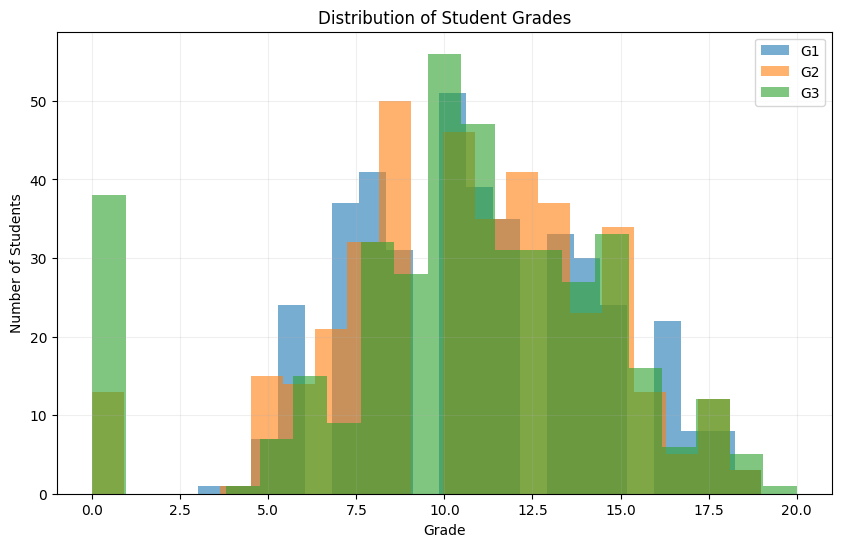

In [21]:
# ============================================================
# 23. GRADE DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(
    df["G1"],
    bins=21,
    alpha=0.6,
    label="G1"
)

plt.hist(
    df["G2"],
    bins=21,
    alpha=0.6,
    label="G2"
)

plt.hist(
    df["G3"],
    bins=21,
    alpha=0.6,
    label="G3"
)

plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.title("Distribution of Student Grades")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

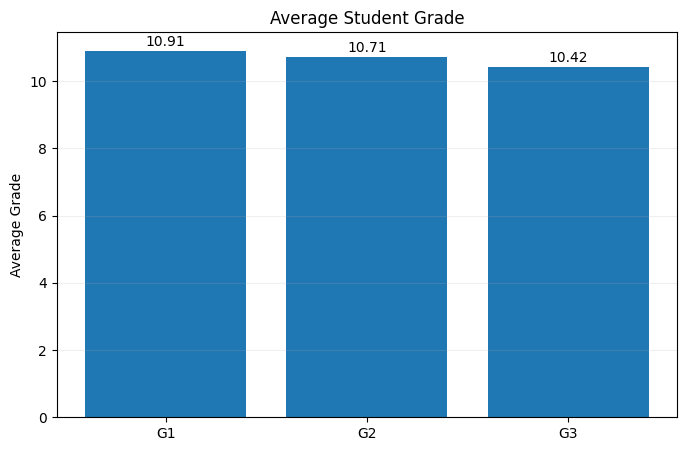

In [22]:
# ============================================================
# 24. AVERAGE GRADE BAR GRAPH
# ============================================================

average_grades = [
    df["G1"].mean(),
    df["G2"].mean(),
    df["G3"].mean()
]

grade_names = [
    "G1",
    "G2",
    "G3"
]

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    grade_names,
    average_grades
)

plt.ylabel("Average Grade")
plt.title("Average Student Grade")
plt.grid(
    axis="y",
    alpha=0.2
)

for i, value in enumerate(
    average_grades
):

    plt.text(
        i,
        value + 0.15,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

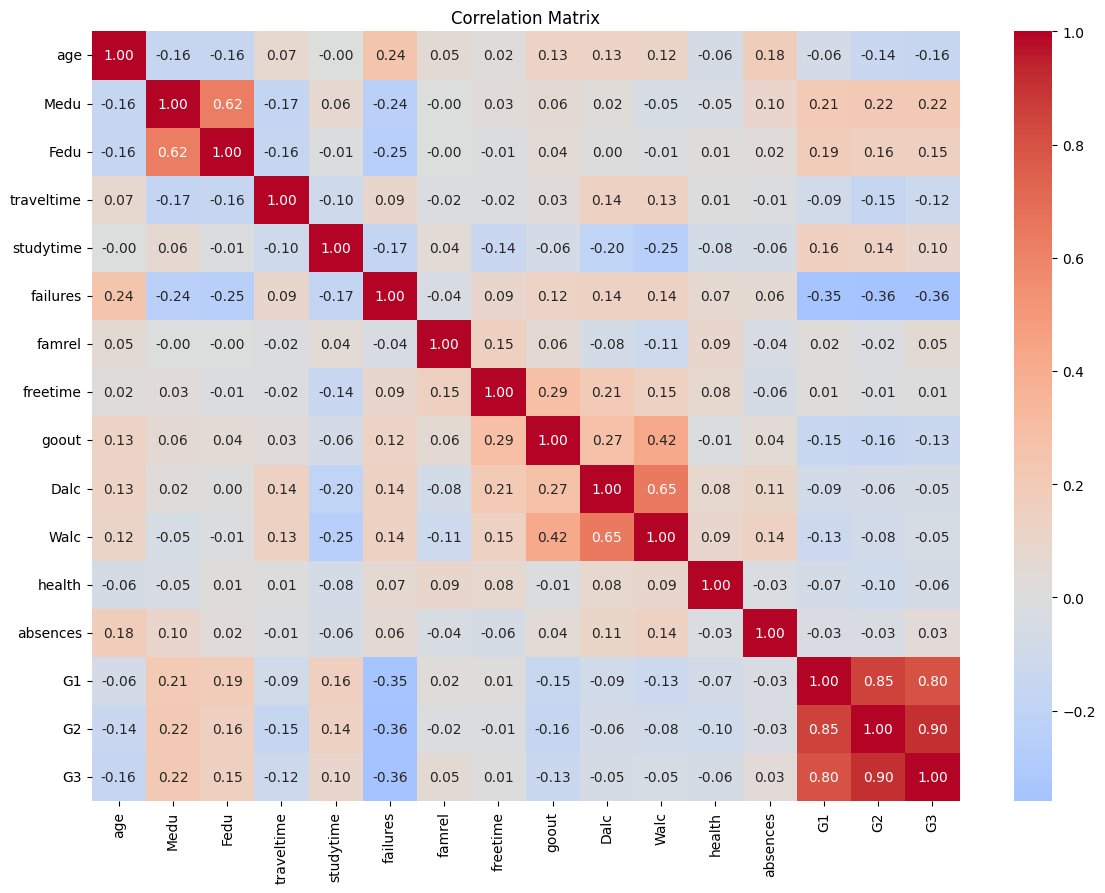

In [23]:
# ============================================================
# 25. CORRELATION ANALYSIS
# ============================================================

numeric_df = df.select_dtypes(
    include=np.number
)

correlation_matrix = numeric_df.corr()

plt.figure(
    figsize=(14, 10)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Matrix"
)

plt.show()

In [24]:
# ============================================================
# 26. CORRELATION WITH FINAL GRADE G3
# ============================================================

g3_correlation = (
    correlation_matrix["G3"]
    .sort_values(
        ascending=False
    )
)

print(
    "\nCorrelation with G3:"
)

display(
    g3_correlation.to_frame(
        "Correlation with G3"
    )
)


Correlation with G3:


,Correlation with G3
G3,1.000000
G2,0.904868
G1,0.801468
Medu,0.217147
Fedu,0.152457
studytime,0.097820
famrel,0.051363
absences,0.034247
freetime,0.011307
Walc,-0.051939


In [25]:
# ============================================================
# 27. SELECT MODEL FEATURES
# ============================================================

context_features = [

    "age",
    "Medu",
    "Fedu",
    "traveltime",
    "studytime",
    "failures",
    "famrel",
    "freetime",
    "goout",
    "Dalc",
    "Walc",
    "health",
    "absences"
]

sequence_features = [
    "G1",
    "G2"
]

target = "G3"

print("\nContext features:")

print(context_features)

print("\nSequence features:")

print(sequence_features)

print("\nTarget:")

print(target)



Context features:
['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences']

Sequence features:
['G1', 'G2']

Target:
G3


In [26]:
# ============================================================
# 28. CREATE MODEL DATA
# ============================================================

model_columns = (
    context_features
    + sequence_features
    + [target]
)

model_df = df[
    model_columns
].copy()

print(
    "\nModel dataset shape:",
    model_df.shape
)


Model dataset shape: (395, 16)


In [27]:
# ============================================================
# 29. TRAIN / VALIDATION / TEST SPLIT
# ============================================================

train_df, temp_df = train_test_split(
    model_df,
    test_size=0.30,
    random_state=SEED
)

validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED
)

train_df = train_df.reset_index(
    drop=True
)

validation_df = validation_df.reset_index(
    drop=True
)

test_df = test_df.reset_index(
    drop=True
)

print("\nDataset split:")

print(
    "Training:",
    train_df.shape
)

print(
    "Validation:",
    validation_df.shape
)

print(
    "Testing:",
    test_df.shape
)

print(
    "\nTrain percentage:",
    len(train_df) / len(model_df) * 100
)

print(
    "Validation percentage:",
    len(validation_df) / len(model_df) * 100
)

print(
    "Test percentage:",
    len(test_df) / len(model_df) * 100
)


Dataset split:
Training: (276, 16)
Validation: (59, 16)
Testing: (60, 16)

Train percentage: 69.87341772151898
Validation percentage: 14.936708860759493
Test percentage: 15.18987341772152


In [28]:
# ============================================================
# 30. NORMALIZATION
# ============================================================

context_scaler = StandardScaler()

grade_scaler = StandardScaler()

target_scaler = StandardScaler()

# Fit ONLY on training data

context_scaler.fit(
    train_df[
        context_features
    ]
)

grade_scaler.fit(
    train_df[
        ["G1", "G2"]
    ].values.reshape(
        -1,
        1
    )
)

target_scaler.fit(
    train_df[
        [target]
    ]
)

StandardScaler()

In [29]:
# ============================================================
# 31. FUNCTION FOR SEQUENCE CREATION
# ============================================================

def create_sequences(dataframe):

    context_scaled = context_scaler.transform(
        dataframe[
            context_features
        ]
    )

    grades = dataframe[
        ["G1", "G2"]
    ].values

    grades_scaled = grade_scaler.transform(
        grades.reshape(
            -1,
            1
        )
    ).reshape(
        -1,
        2
    )

    X = []

    y = []

    for i in range(
        len(dataframe)
    ):

        timestep_1 = np.concatenate(
            [
                context_scaled[i],
                [
                    grades_scaled[i, 0]
                ]
            ]
        )

        timestep_2 = np.concatenate(
            [
                context_scaled[i],
                [
                    grades_scaled[i, 1]
                ]
            ]
        )

        sequence = np.vstack(
            [
                timestep_1,
                timestep_2
            ]
        )

        X.append(sequence)

        y.append(
            dataframe.iloc[
                i
            ][target]
        )

    X = np.array(
        X,
        dtype=np.float32
    )

    y = np.array(
        y,
        dtype=np.float32
    )

    return X, y


In [30]:
# ============================================================
# 32. CREATE TRAINING SEQUENCES
# ============================================================

X_train, y_train = create_sequences(
    train_df
)

# ============================================================
# 33. CREATE VALIDATION SEQUENCES
# ============================================================

X_val, y_val = create_sequences(
    validation_df
)

# ============================================================
# 34. CREATE TEST SEQUENCES
# ============================================================

X_test, y_test = create_sequences(
    test_df
)

# ============================================================
# 35. NORMALIZE TARGET
# ============================================================

y_train_scaled = target_scaler.transform(
    y_train.reshape(
        -1,
        1
    )
).ravel()

y_val_scaled = target_scaler.transform(
    y_val.reshape(
        -1,
        1
    )
).ravel()

y_test_scaled = target_scaler.transform(
    y_test.reshape(
        -1,
        1
    )
).ravel()

In [31]:
# ============================================================
# 36. DISPLAY SEQUENCE SHAPES
# ============================================================

print("\nSequence shapes:")

print(
    "X_train:",
    X_train.shape
)

print(
    "y_train:",
    y_train_scaled.shape
)

print(
    "X_validation:",
    X_val.shape
)

print(
    "y_validation:",
    y_val_scaled.shape
)

print(
    "X_test:",
    X_test.shape
)

print(
    "y_test:",
    y_test_scaled.shape
)

print(
    "\nSequence meaning:"
)

print(
    "Number of timesteps:",
    X_train.shape[1]
)

print(
    "Features per timestep:",
    X_train.shape[2]
)


Sequence shapes:
X_train: (276, 2, 14)
y_train: (276,)
X_validation: (59, 2, 14)
y_validation: (59,)
X_test: (60, 2, 14)
y_test: (60,)

Sequence meaning:
Number of timesteps: 2
Features per timestep: 14


In [32]:
# ============================================================
# 37. MODEL HYPERPARAMETERS
# ============================================================

LEARNING_RATE = 0.001

BATCH_SIZE = 16

EPOCHS = 100

EARLY_STOPPING_PATIENCE = 15

REDUCE_LR_PATIENCE = 7

DROPOUT_RATE = 0.30

RNN_UNITS_1 = 64

RNN_UNITS_2 = 32

DENSE_UNITS = 16

print("\nModel hyperparameters:")

print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Batch size:",
    BATCH_SIZE
)

print(
    "Maximum epochs:",
    EPOCHS
)

print(
    "Early stopping patience:",
    EARLY_STOPPING_PATIENCE
)

print(
    "Reduce LR patience:",
    REDUCE_LR_PATIENCE
)

print(
    "Dropout:",
    DROPOUT_RATE
)

print(
    "First recurrent layer:",
    RNN_UNITS_1
)

print(
    "Second recurrent layer:",
    RNN_UNITS_2
)

print(
    "Dense units:",
    DENSE_UNITS
)


Model hyperparameters:
Learning rate: 0.001
Batch size: 16
Maximum epochs: 100
Early stopping patience: 15
Reduce LR patience: 7
Dropout: 0.3
First recurrent layer: 64
Second recurrent layer: 32
Dense units: 16


In [33]:
# ============================================================
# 38. CREATE SIMPLE RNN MODEL
# ============================================================

def build_rnn_model():

    model = Sequential(
        [

            Input(
                shape=(
                    X_train.shape[1],
                    X_train.shape[2]
                )
            ),

            SimpleRNN(
                RNN_UNITS_1,
                return_sequences=True
            ),

            Dropout(
                DROPOUT_RATE
            ),

            SimpleRNN(
                RNN_UNITS_2
            ),

            Dropout(
                DROPOUT_RATE
            ),

            Dense(
                DENSE_UNITS,
                activation="relu"
            ),

            Dense(
                1,
                activation="linear"
            )
        ]
    )

    model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [34]:
# ============================================================
# 39. CREATE LSTM MODEL
# ============================================================

def build_lstm_model():

    model = Sequential(
        [

            Input(
                shape=(
                    X_train.shape[1],
                    X_train.shape[2]
                )
            ),

            LSTM(
                RNN_UNITS_1,
                return_sequences=True
            ),

            Dropout(
                DROPOUT_RATE
            ),

            LSTM(
                RNN_UNITS_2
            ),

            Dropout(
                DROPOUT_RATE
            ),

            Dense(
                DENSE_UNITS,
                activation="relu"
            ),

            Dense(
                1,
                activation="linear"
            )
        ]
    )

    model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [35]:
# ============================================================
# 40. CREATE GRU MODEL
# ============================================================

def build_gru_model():

    model = Sequential(
        [

            Input(
                shape=(
                    X_train.shape[1],
                    X_train.shape[2]
                )
            ),

            GRU(
                RNN_UNITS_1,
                return_sequences=True
            ),

            Dropout(
                DROPOUT_RATE
            ),

            GRU(
                RNN_UNITS_2
            ),

            Dropout(
                DROPOUT_RATE
            ),

            Dense(
                DENSE_UNITS,
                activation="relu"
            ),

            Dense(
                1,
                activation="linear"
            )
        ]
    )

    model.compile(
        optimizer=Adam(
            learning_rate=LEARNING_RATE
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model


In [36]:
# ============================================================
# 41. CREATE MODELS
# ============================================================

models = {

    "RNN":
        build_rnn_model(),

    "LSTM":
        build_lstm_model(),

    "GRU":
        build_gru_model()
}

In [37]:
# ============================================================
# 42. DISPLAY MODEL ARCHITECTURES
# ============================================================

for name, model in models.items():

    print("\n" + "=" * 70)

    print(
        f"{name} MODEL ARCHITECTURE"
    )

    print("=" * 70)

    model.summary()



RNN MODEL ARCHITECTURE


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 2, 64)          │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

...

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 2, 64)          │        15,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,313 (98.88 KB)

 Trainable params: 25,313 (98.88 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# ============================================================
# 43. CALLBACK FUNCTION
# ============================================================

def get_callbacks():

    early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=EARLY_STOPPING_PATIENCE,
        restore_best_weights=True,
        verbose=1
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=REDUCE_LR_PATIENCE,
        min_lr=1e-6,
        verbose=1
    )

    return [
        early_stopping,
        reduce_lr
    ]

In [39]:
# ============================================================
# 44. TRAIN ALL MODELS
# ============================================================

histories = {}

training_times = {}

for name, model in models.items():

    print("\n")
    print("=" * 80)
    print(
        f"TRAINING {name}"
    )
    print("=" * 80)

    start_time = time.time()

    history = model.fit(

        X_train,
        y_train_scaled,

        validation_data=(
            X_val,
            y_val_scaled
        ),

        epochs=EPOCHS,

        batch_size=BATCH_SIZE,

        callbacks=get_callbacks(),

        verbose=1
    )

    end_time = time.time()

    histories[name] = history

    training_times[name] = (
        end_time - start_time
    )

    print(
        f"\n{name} training time:"
        f" {training_times[name]:.2f} seconds"
    )



TRAINING RNN
Epoch 1/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - loss: 1.0994 - mae: 0.7879 - val_loss: 0.8812 - val_mae: 0.6719 - learning_rate: 0.0010
Epoch 2/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6256 - mae: 0.5846 - val_loss: 0.6272 - val_mae: 0.5404 - learning_rate: 0.0010
Epoch 3/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5426 - mae: 0.5568 - val_loss: 0.5275 - val_mae: 0.5040 - learning_rate: 0.0010
Epoch 4/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3983 - mae: 0.4924 - val_loss: 0.4425 - val_mae: 0.4909 - learning_rate: 0.0010
Epoch 5/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4318 - mae: 0.5061 - val_loss: 0.3832 - val_mae: 0.4721 - learning_rate: 0.0010
Epoch 6/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3281 - mae: 0.4544 - val_loss: 0.3401 - val_mae: 0.4428 - learning_rate: 0.0010
Epoch 7/100
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3266 - mae: 0.4431 - val_loss: 0.3318 - val_mae: 0.4238 - learning_rate: 0.

In [40]:
# ============================================================
# 45. TRAINING HISTORY TABLES
# ============================================================

for name, history in histories.items():

    print("\n")
    print("=" * 80)
    print(
        f"{name} COMPLETE TRAINING HISTORY"
    )
    print("=" * 80)

    history_df = pd.DataFrame(
        history.history
    )

    history_df.index = (
        history_df.index + 1
    )

    history_df.index.name = "Epoch"

    display(
        history_df
    )



RNN COMPLETE TRAINING HISTORY


,loss,mae,val_loss,val_mae,learning_rate
Epoch,,,,,
1,1.099432,0.787864,0.881214,0.671890,0.001000
2,0.625632,0.584556,0.627182,0.540449,0.001000
3,0.542577,0.556819,0.527531,0.503952,0.001000
4,0.398328,0.492426,0.442505,0.490900,0.001000
5,0.431832,0.506145,0.383250,0.472137,0.001000
6,0.328054,0.454373,0.340060,0.442789,0.001000
7,0.326628,0.443092,0.331751,0.423758,0.001000
8,0.322764,0.446333,0.315300,0.405495,0.001000
9,0.335730,0.436434,0.299320,0.409312,0.001000




LSTM COMPLETE TRAINING HISTORY


,loss,mae,val_loss,val_mae,learning_rate
Epoch,,,,,
1,0.956092,0.713428,1.036066,0.777859,0.00100
2,0.815217,0.652773,0.825942,0.679395,0.00100
3,0.593894,0.566086,0.555271,0.547220,0.00100
4,0.401955,0.464980,0.336351,0.397382,0.00100
5,0.289579,0.401712,0.275561,0.368207,0.00100
6,0.239624,0.360334,0.270239,0.369849,0.00100
7,0.224788,0.357445,0.277742,0.376892,0.00100
8,0.220147,0.342886,0.275999,0.381759,0.00100
9,0.233337,0.354693,0.269756,0.375907,0.00100




GRU COMPLETE TRAINING HISTORY


,loss,mae,val_loss,val_mae,learning_rate
Epoch,,,,,
1,0.920795,0.695372,0.971632,0.729766,0.00100
2,0.681100,0.598990,0.714644,0.617465,0.00100
3,0.469672,0.508806,0.460154,0.473176,0.00100
4,0.314642,0.418678,0.320210,0.375261,0.00100
5,0.279563,0.381850,0.269685,0.339951,0.00100
6,0.254090,0.370100,0.256562,0.344077,0.00100
7,0.216049,0.368742,0.288612,0.370740,0.00100
8,0.212377,0.347576,0.286870,0.358357,0.00100
9,0.228717,0.358837,0.283317,0.362027,0.00100


In [41]:
# ============================================================
# 46. GET BEST EPOCH INFORMATION
# ============================================================

training_summary = []

for name, history in histories.items():

    hist_df = pd.DataFrame(
        history.history
    )

    best_epoch = (
        hist_df["val_loss"]
        .idxmin()
        + 1
    )

    best_val_loss = (
        hist_df["val_loss"]
        .min()
    )

    final_train_loss = (
        hist_df["loss"].iloc[-1]
    )

    final_val_loss = (
        hist_df["val_loss"].iloc[-1]
    )

    final_train_mae = (
        hist_df["mae"].iloc[-1]
    )

    final_val_mae = (
        hist_df["val_mae"].iloc[-1]
    )

    training_summary.append(

        {

            "Model":
                name,

            "Epochs_Completed":
                len(hist_df),

            "Best_Epoch":
                best_epoch,

            "Best_Validation_Loss":
                best_val_loss,

            "Final_Training_Loss":
                final_train_loss,

            "Final_Validation_Loss":
                final_val_loss,

            "Final_Training_MAE":
                final_train_mae,

            "Final_Validation_MAE":
                final_val_mae,

            "Training_Time_Seconds":
                training_times[name]
        }
    )

training_summary_df = pd.DataFrame(
    training_summary
)

print(
    "\nTraining summary:"
)

display(
    training_summary_df
)


Training summary:


,Model,Epochs_Completed,Best_Epoch,Best_Validation_Loss,Final_Training_Loss,Final_Validation_Loss,Final_Training_MAE,Final_Validation_MAE,Training_Time_Seconds
0,RNN,56,41,0.222146,0.142210,0.228313,0.284940,0.356689,26.152072
1,LSTM,24,9,0.269756,0.156984,0.287650,0.296066,0.378738,10.455437
2,GRU,21,6,0.256562,0.131448,0.275151,0.287896,0.363145,6.534282


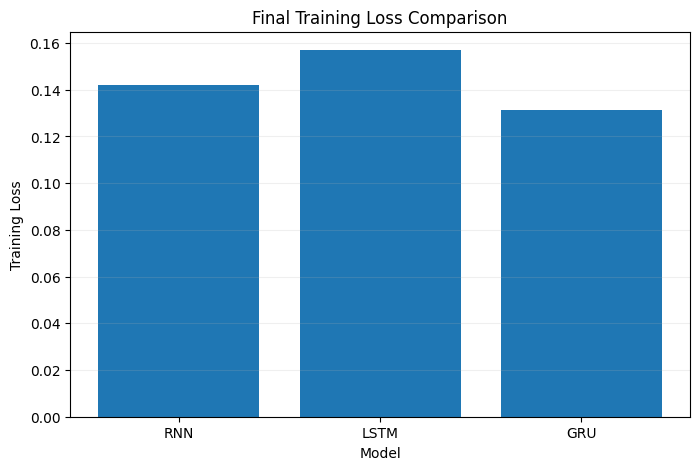

In [42]:
# ============================================================
# 47. BAR GRAPH - FINAL TRAINING LOSS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    training_summary_df["Model"],
    training_summary_df[
        "Final_Training_Loss"
    ]
)

plt.xlabel("Model")
plt.ylabel("Training Loss")
plt.title(
    "Final Training Loss Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

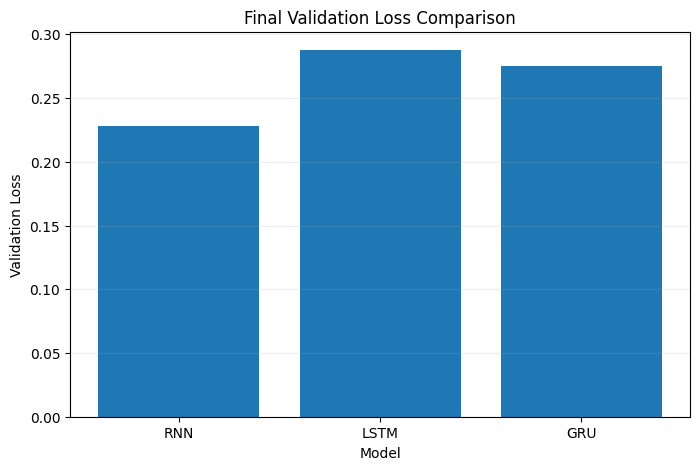

In [43]:
# ============================================================
# 48. BAR GRAPH - FINAL VALIDATION LOSS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    training_summary_df["Model"],
    training_summary_df[
        "Final_Validation_Loss"
    ]
)

plt.xlabel("Model")
plt.ylabel("Validation Loss")
plt.title(
    "Final Validation Loss Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()


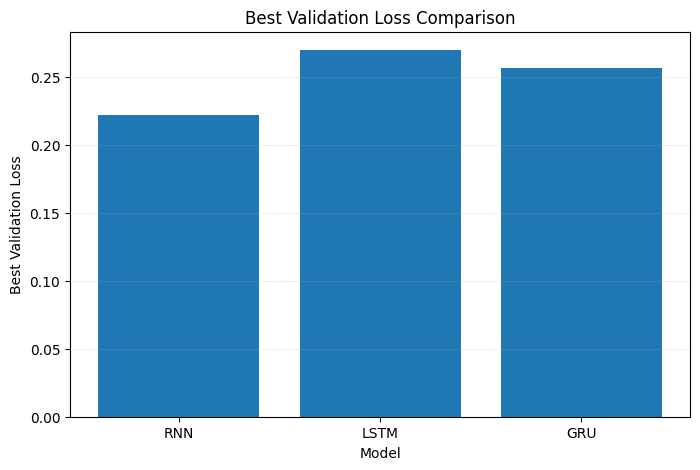

In [44]:
# ============================================================
# 49. BAR GRAPH - BEST VALIDATION LOSS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    training_summary_df["Model"],
    training_summary_df[
        "Best_Validation_Loss"
    ]
)

plt.xlabel("Model")
plt.ylabel("Best Validation Loss")
plt.title(
    "Best Validation Loss Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

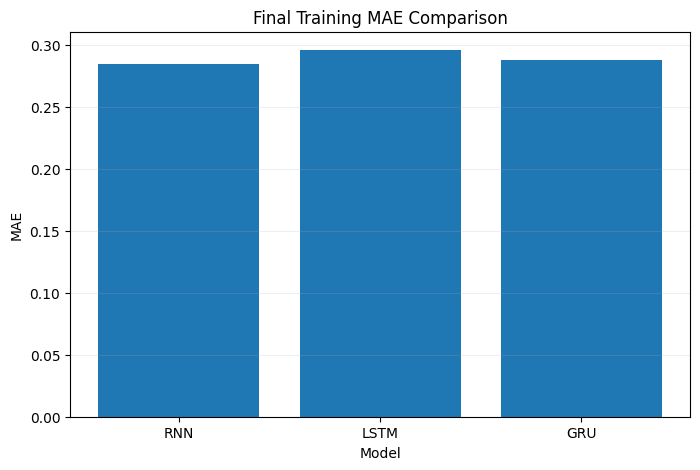

In [45]:
# ============================================================
# 50. BAR GRAPH - TRAINING MAE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    training_summary_df["Model"],
    training_summary_df[
        "Final_Training_MAE"
    ]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title(
    "Final Training MAE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()


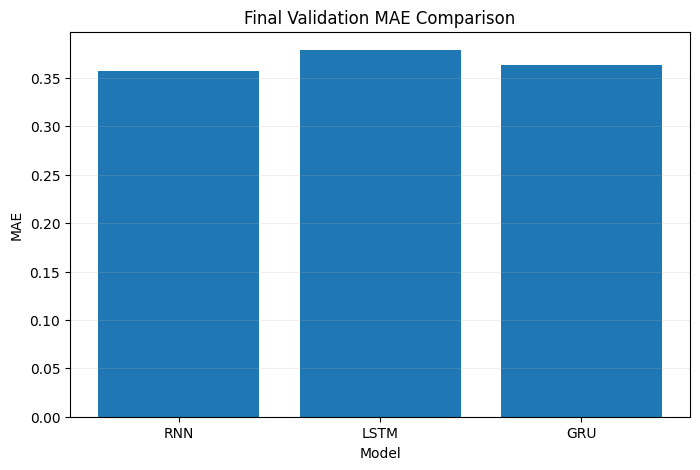

In [46]:
# ============================================================
# 51. BAR GRAPH - VALIDATION MAE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    training_summary_df["Model"],
    training_summary_df[
        "Final_Validation_MAE"
    ]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title(
    "Final Validation MAE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()


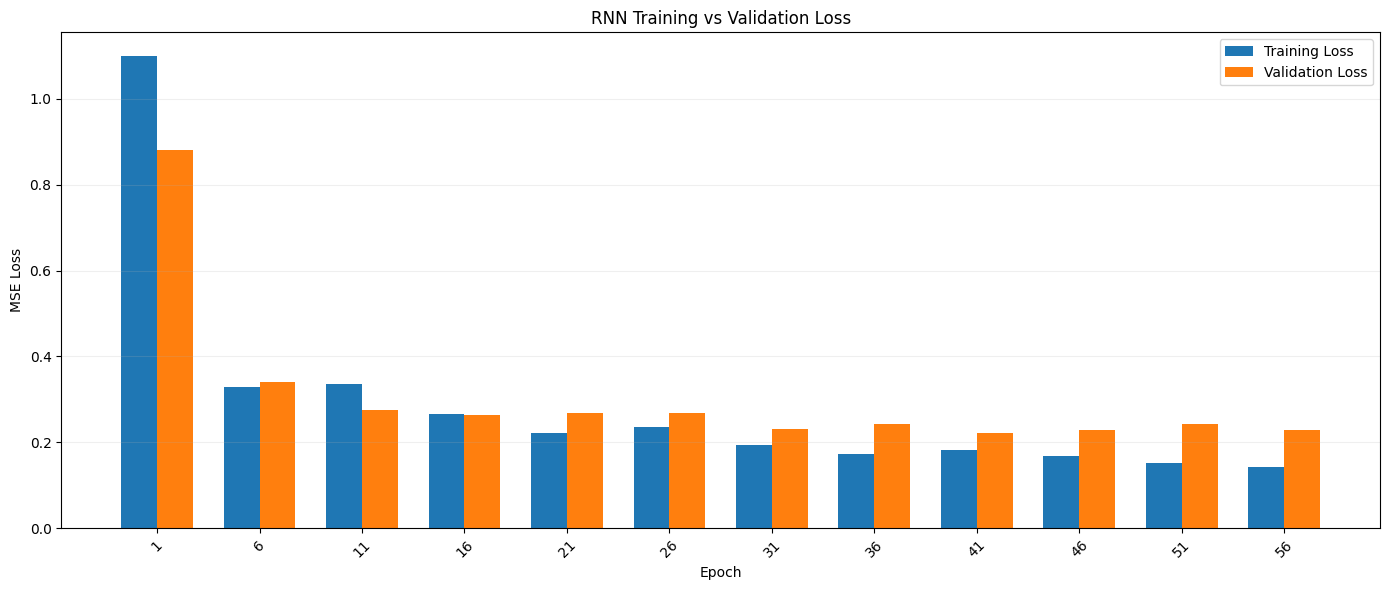

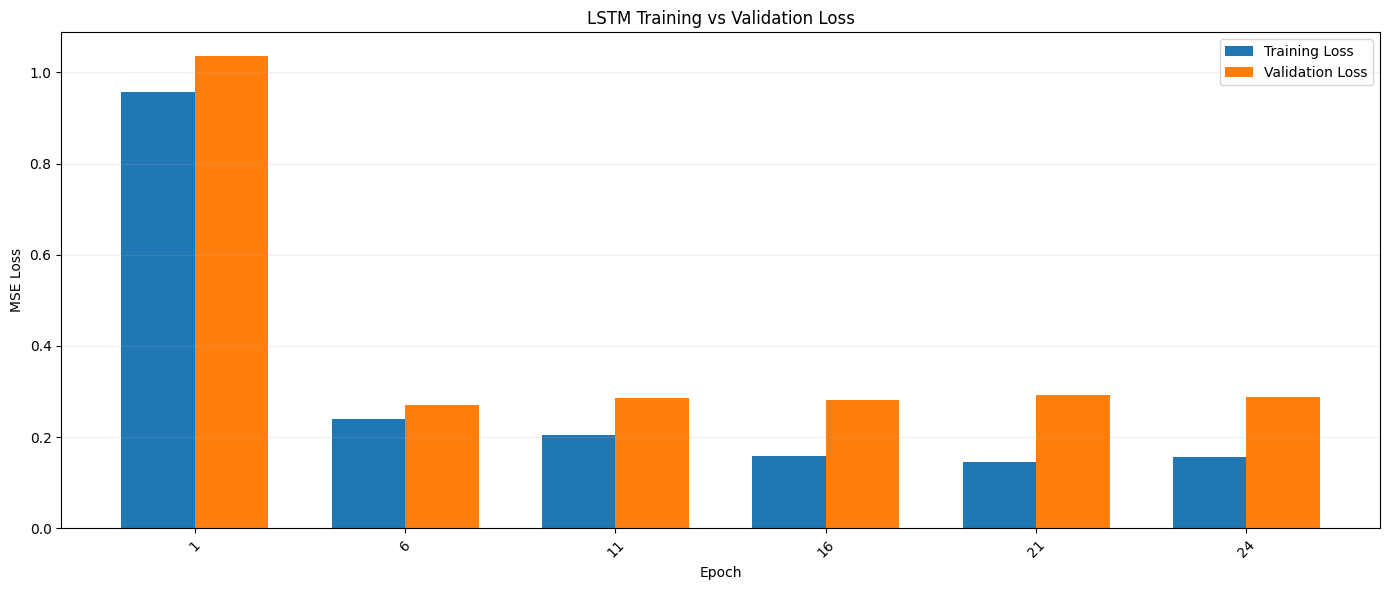

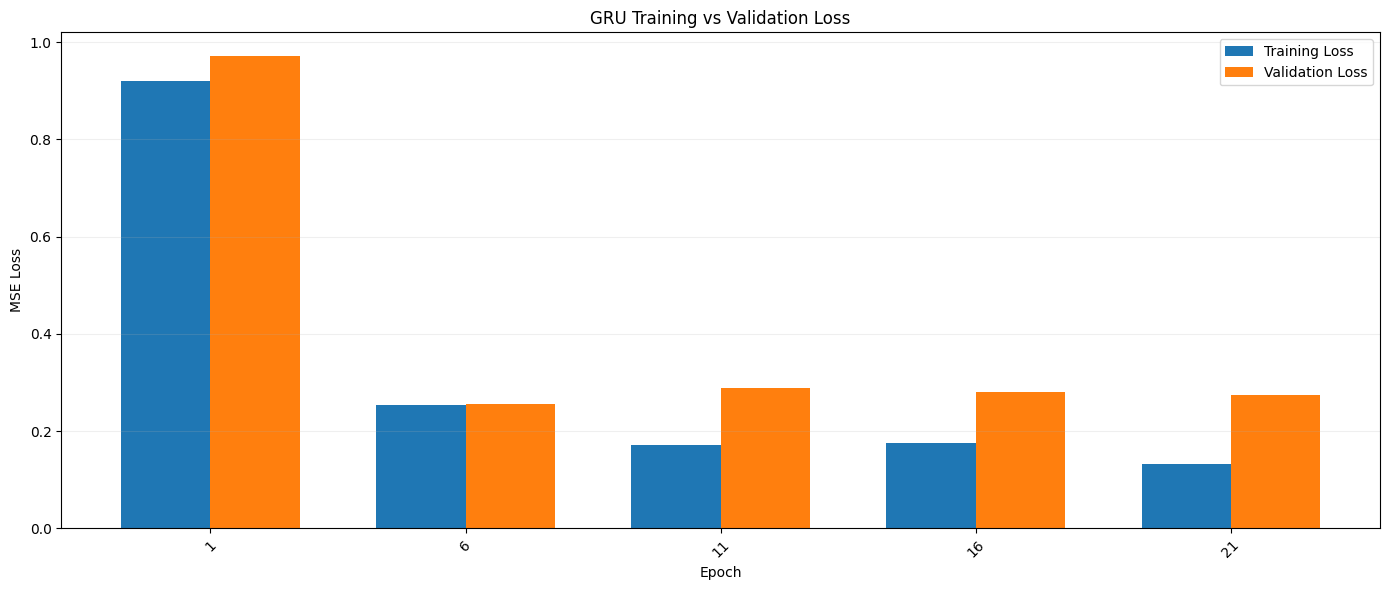

In [47]:
# ============================================================
# 52. EPOCH-BY-EPOCH BAR GRAPH
#     EVERY 5 EPOCHS
# ============================================================

for name, history in histories.items():

    hist_df = pd.DataFrame(
        history.history
    )

    selected_epochs = list(
        range(
            0,
            len(hist_df),
            5
        )
    )

    if (
        len(hist_df) - 1
    ) not in selected_epochs:

        selected_epochs.append(
            len(hist_df) - 1
        )

    selected_epochs = sorted(
        selected_epochs
    )

    epochs_display = [
        e + 1
        for e in selected_epochs
    ]

    train_values = [
        hist_df.iloc[e]["loss"]
        for e in selected_epochs
    ]

    val_values = [
        hist_df.iloc[e]["val_loss"]
        for e in selected_epochs
    ]

    x = np.arange(
        len(epochs_display)
    )

    width = 0.35

    plt.figure(
        figsize=(14, 6)
    )

    plt.bar(
        x - width / 2,
        train_values,
        width,
        label="Training Loss"
    )

    plt.bar(
        x + width / 2,
        val_values,
        width,
        label="Validation Loss"
    )

    plt.xticks(
        x,
        epochs_display,
        rotation=45
    )

    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")

    plt.title(
        f"{name} Training vs Validation Loss"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.2
    )

    plt.tight_layout()

    plt.show()

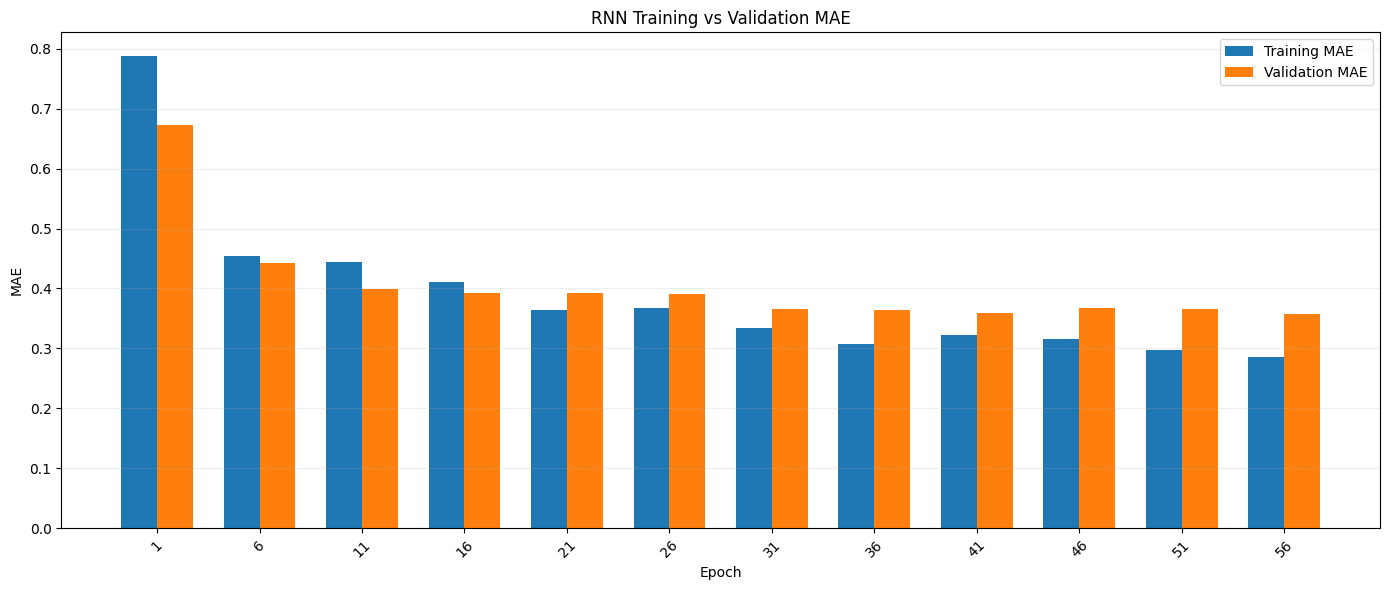

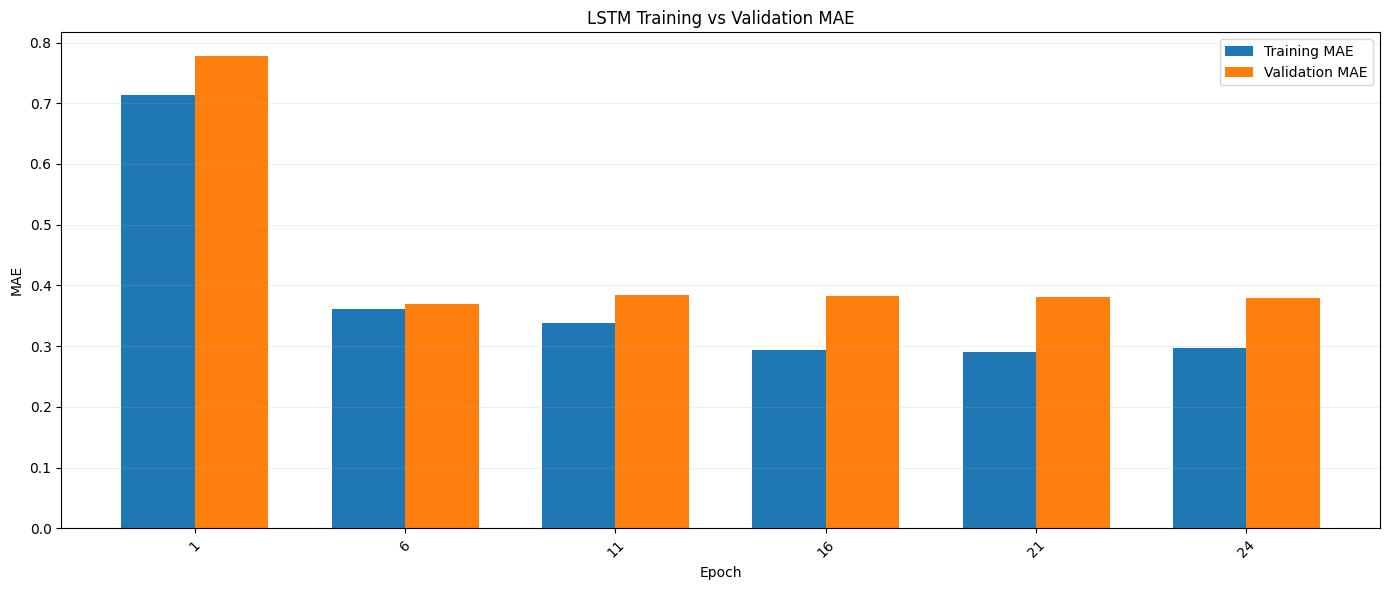

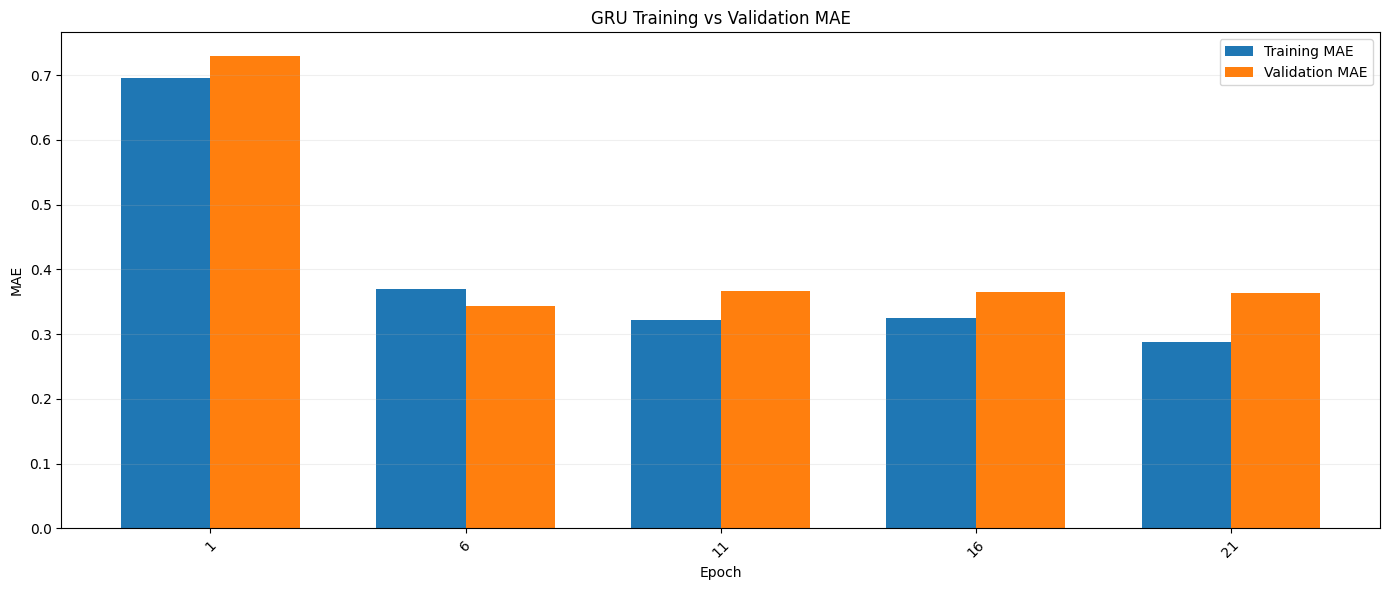

In [48]:
# ============================================================
# 53. EPOCH-BY-EPOCH MAE BAR GRAPHS
# ============================================================

for name, history in histories.items():

    hist_df = pd.DataFrame(
        history.history
    )

    selected_epochs = list(
        range(
            0,
            len(hist_df),
            5
        )
    )

    if (
        len(hist_df) - 1
    ) not in selected_epochs:

        selected_epochs.append(
            len(hist_df) - 1
        )

    selected_epochs = sorted(
        selected_epochs
    )

    epochs_display = [
        e + 1
        for e in selected_epochs
    ]

    train_values = [
        hist_df.iloc[e]["mae"]
        for e in selected_epochs
    ]

    val_values = [
        hist_df.iloc[e]["val_mae"]
        for e in selected_epochs
    ]

    x = np.arange(
        len(epochs_display)
    )

    width = 0.35

    plt.figure(
        figsize=(14, 6)
    )

    plt.bar(
        x - width / 2,
        train_values,
        width,
        label="Training MAE"
    )

    plt.bar(
        x + width / 2,
        val_values,
        width,
        label="Validation MAE"
    )

    plt.xticks(
        x,
        epochs_display,
        rotation=45
    )

    plt.xlabel("Epoch")
    plt.ylabel("MAE")

    plt.title(
        f"{name} Training vs Validation MAE"
    )

    plt.legend()

    plt.grid(
        axis="y",
        alpha=0.2
    )

    plt.tight_layout()

    plt.show()

In [49]:
# ============================================================
# 54. MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(
    model,
    X,
    y_true
):

    predictions_scaled = model.predict(
        X,
        verbose=0
    )

    predictions = target_scaler.inverse_transform(
        predictions_scaled
    ).ravel()

    y_true = np.array(
        y_true
    ).ravel()

    mae = mean_absolute_error(
        y_true,
        predictions
    )

    mse = mean_squared_error(
        y_true,
        predictions
    )

    rmse = np.sqrt(
        mse
    )

    r2 = r2_score(
        y_true,
        predictions
    )

    explained_variance = (
        explained_variance_score(
            y_true,
            predictions
        )
    )

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "Explained_Variance":
            explained_variance,
        "Predictions":
            predictions
    }


In [50]:
# ============================================================
# 55. VALIDATION EVALUATION
# ============================================================

validation_results = {}

for name, model in models.items():

    validation_results[name] = evaluate_model(
        model,
        X_val,
        y_val
    )

validation_table = []

for name, result in validation_results.items():

    validation_table.append(

        {

            "Model":
                name,

            "Validation_MAE":
                result["MAE"],

            "Validation_MSE":
                result["MSE"],

            "Validation_RMSE":
                result["RMSE"],

            "Validation_R2":
                result["R2"],

            "Validation_Explained_Variance":
                result[
                    "Explained_Variance"
                ]
        }
    )

validation_df_results = pd.DataFrame(
    validation_table
)

print(
    "\nVALIDATION RESULTS"
)

display(
    validation_df_results
)


VALIDATION RESULTS


,Model,Validation_MAE,Validation_MSE,Validation_RMSE,Validation_R2,Validation_Explained_Variance
0,RNN,1.626591,4.549552,2.132968,0.810140,0.811422
1,LSTM,1.701160,5.524608,2.350448,0.769449,0.771968
2,GRU,1.557113,5.254395,2.292247,0.780726,0.783777


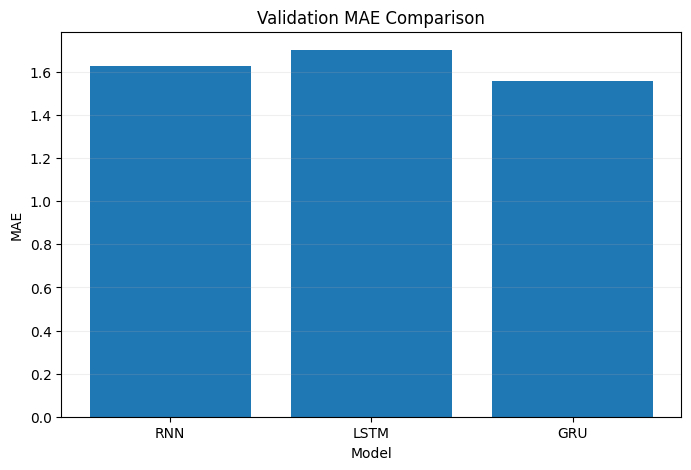

In [51]:
# ============================================================
# 56. VALIDATION BAR GRAPH - MAE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    validation_df_results["Model"],
    validation_df_results[
        "Validation_MAE"
    ]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title(
    "Validation MAE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

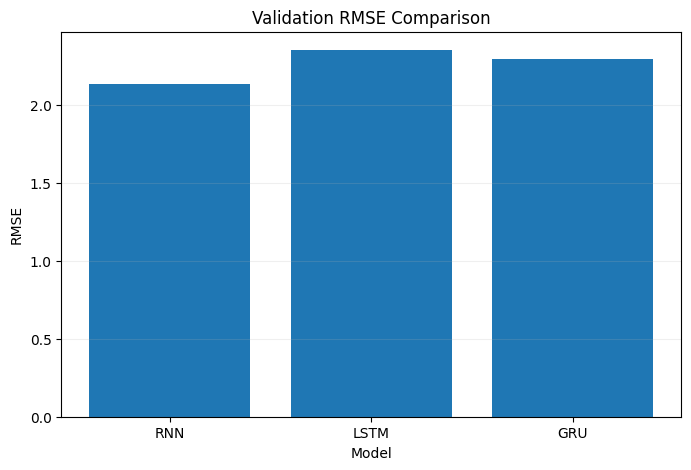

In [52]:
# ============================================================
# 57. VALIDATION BAR GRAPH - RMSE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    validation_df_results["Model"],
    validation_df_results[
        "Validation_RMSE"
    ]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title(
    "Validation RMSE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

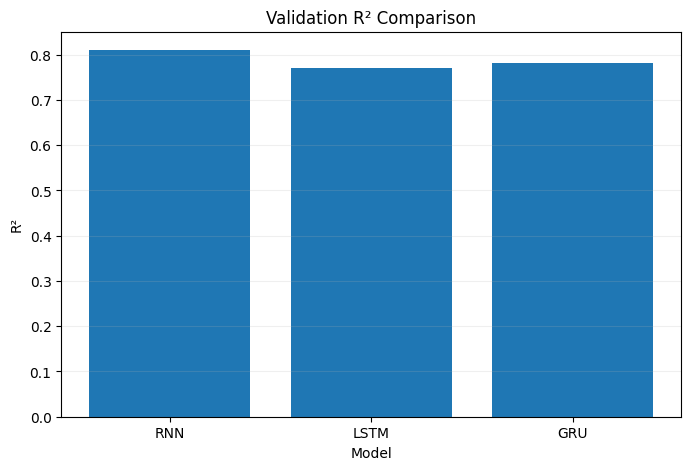

In [53]:
# ============================================================
# 58. VALIDATION BAR GRAPH - R2
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    validation_df_results["Model"],
    validation_df_results[
        "Validation_R2"
    ]
)

plt.xlabel("Model")
plt.ylabel("R²")
plt.title(
    "Validation R² Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()


In [54]:
# ============================================================
# 59. TEST EVALUATION
# ============================================================

test_results = {}

test_prediction_tables = {}

for name, model in models.items():

    result = evaluate_model(
        model,
        X_test,
        y_test
    )

    test_results[name] = result

    predictions = result[
        "Predictions"
    ]

    errors = (
        y_test - predictions
    )

    absolute_errors = np.abs(
        errors
    )

    squared_errors = (
        errors ** 2
    )

    test_prediction_tables[name] = pd.DataFrame(

        {

            "Actual_G3":
                y_test,

            "Predicted_G3":
                predictions,

            "Error":
                errors,

            "Absolute_Error":
                absolute_errors,

            "Squared_Error":
                squared_errors
        }
    )

In [55]:
# ============================================================
# 60. TEST RESULTS TABLE
# ============================================================

test_table = []

for name, result in test_results.items():

    predictions = result[
        "Predictions"
    ]

    mae = result["MAE"]

    mse = result["MSE"]

    rmse = result["RMSE"]

    r2 = result["R2"]

    ev = result[
        "Explained_Variance"
    ]

    within_1 = np.mean(
        np.abs(
            y_test - predictions
        ) <= 1.0
    ) * 100

    within_2 = np.mean(
        np.abs(
            y_test - predictions
        ) <= 2.0
    ) * 100

    test_table.append(

        {

            "Model":
                name,

            "Test_MAE":
                mae,

            "Test_MSE":
                mse,

            "Test_RMSE":
                rmse,

            "Test_R2":
                r2,

            "Test_Explained_Variance":
                ev,

            "Within_1_Grade_%":
                within_1,

            "Within_2_Grades_%":
                within_2
        }
    )

test_results_df = pd.DataFrame(
    test_table
)

print(
    "\nFINAL TEST RESULTS"
)

display(
    test_results_df
)



FINAL TEST RESULTS


,Model,Test_MAE,Test_MSE,Test_RMSE,Test_R2,Test_Explained_Variance,Within_1_Grade_%,Within_2_Grades_%
0,RNN,1.605542,5.996262,2.448727,0.700619,0.707089,45.0,73.333333
1,LSTM,1.700649,5.110537,2.260650,0.744842,0.749309,40.0,68.333333
2,GRU,1.561832,4.521557,2.126395,0.774248,0.778203,45.0,75.000000


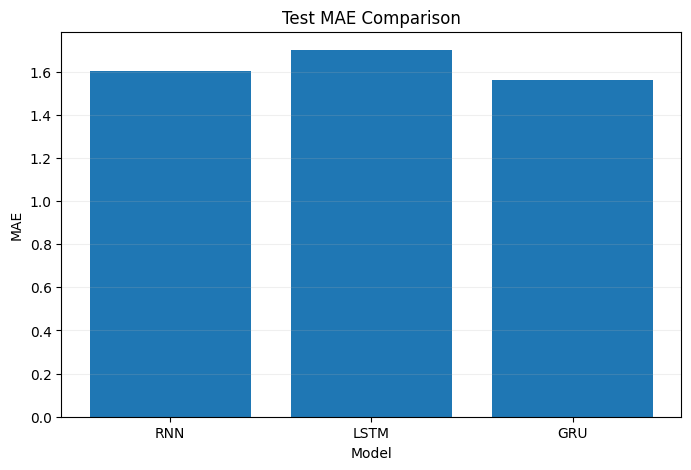

In [56]:
# ============================================================
# 61. TEST BAR GRAPH - MAE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    test_results_df["Model"],
    test_results_df[
        "Test_MAE"
    ]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title(
    "Test MAE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

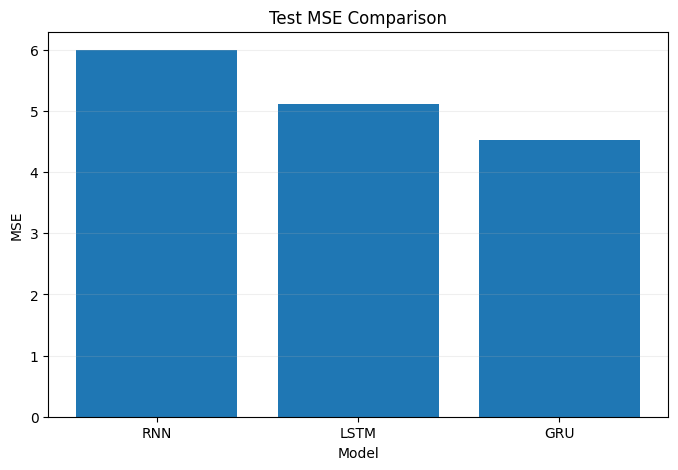

In [57]:
# ============================================================
# 62. TEST BAR GRAPH - MSE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    test_results_df["Model"],
    test_results_df[
        "Test_MSE"
    ]
)

plt.xlabel("Model")
plt.ylabel("MSE")
plt.title(
    "Test MSE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()


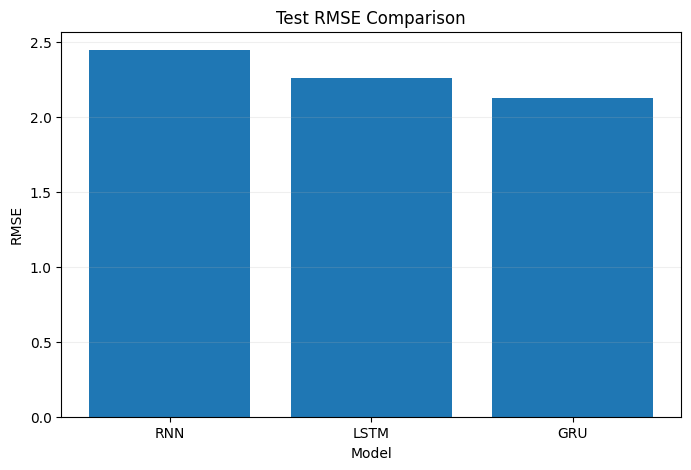

In [58]:
# ============================================================
# 63. TEST BAR GRAPH - RMSE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    test_results_df["Model"],
    test_results_df[
        "Test_RMSE"
    ]
)

plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title(
    "Test RMSE Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()


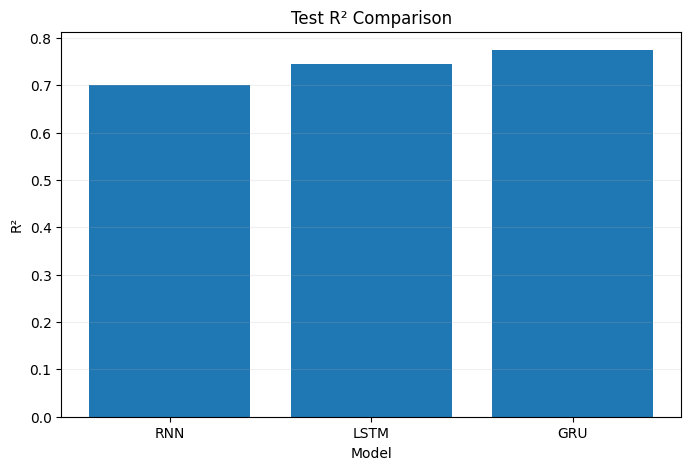

In [59]:
# ============================================================
# 64. TEST BAR GRAPH - R2
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    test_results_df["Model"],
    test_results_df[
        "Test_R2"
    ]
)

plt.xlabel("Model")
plt.ylabel("R²")
plt.title(
    "Test R² Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

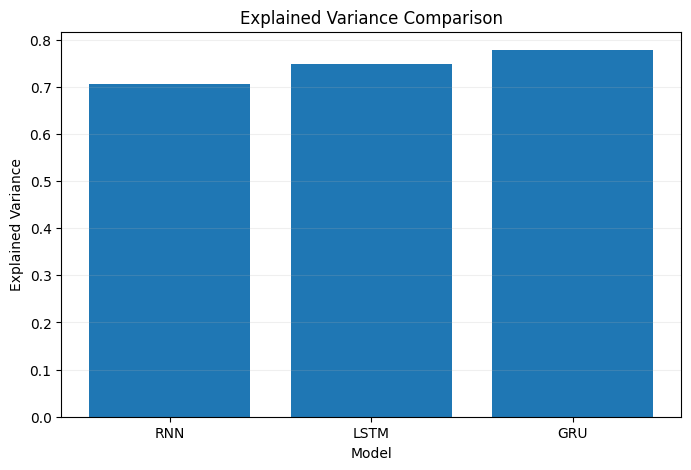

In [60]:
# ============================================================
# 65. TEST BAR GRAPH - EXPLAINED VARIANCE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    test_results_df["Model"],
    test_results_df[
        "Test_Explained_Variance"
    ]
)

plt.xlabel("Model")
plt.ylabel("Explained Variance")
plt.title(
    "Explained Variance Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

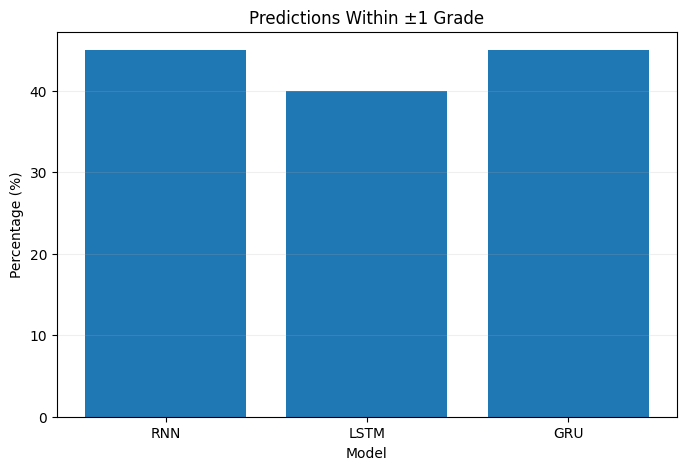

In [61]:
# ============================================================
# 66. TEST BAR GRAPH - WITHIN ±1 GRADE
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    test_results_df["Model"],
    test_results_df[
        "Within_1_Grade_%"
    ]
)

plt.xlabel("Model")
plt.ylabel("Percentage (%)")
plt.title(
    "Predictions Within ±1 Grade"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

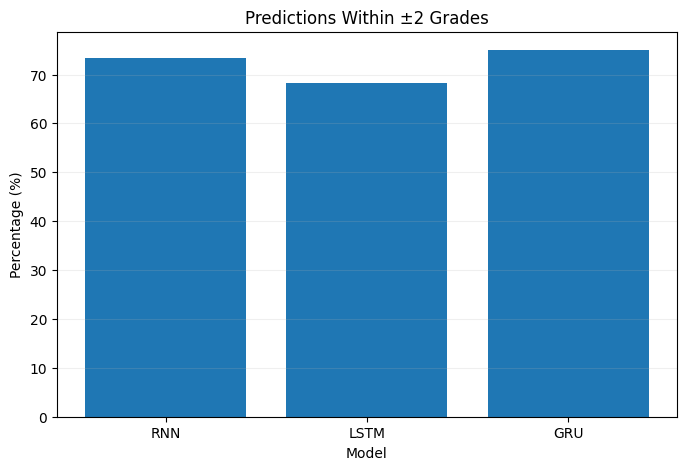

In [62]:
# ============================================================
# 67. TEST BAR GRAPH - WITHIN ±2 GRADES
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    test_results_df["Model"],
    test_results_df[
        "Within_2_Grades_%"
    ]
)

plt.xlabel("Model")
plt.ylabel("Percentage (%)")
plt.title(
    "Predictions Within ±2 Grades"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

In [63]:
# ============================================================
# 68. PARAMETER COUNT
# ============================================================

parameter_results = []

for name, model in models.items():

    parameter_results.append(

        {

            "Model":
                name,

            "Total_Parameters":
                model.count_params()
        }
    )

parameter_df = pd.DataFrame(
    parameter_results
)

print(
    "\nModel parameters:"
)

display(
    parameter_df
)


Model parameters:


,Model,Total_Parameters
0,RNN,8705
1,LSTM,33185
2,GRU,25313


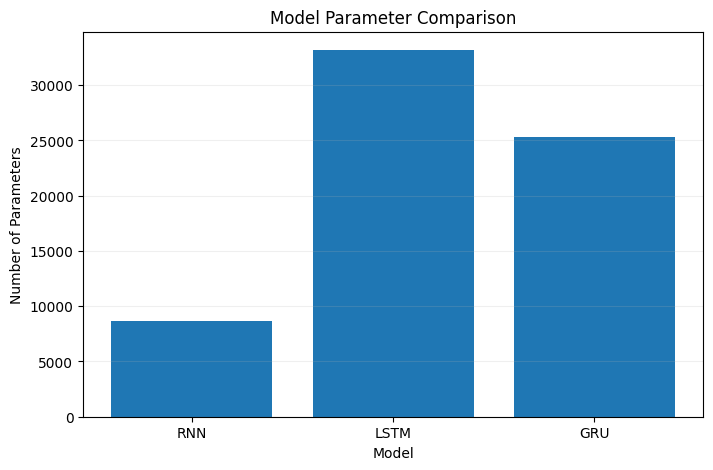

In [64]:
# ============================================================
# 69. PARAMETER BAR GRAPH
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    parameter_df["Model"],
    parameter_df[
        "Total_Parameters"
    ]
)

plt.xlabel("Model")
plt.ylabel("Number of Parameters")
plt.title(
    "Model Parameter Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()


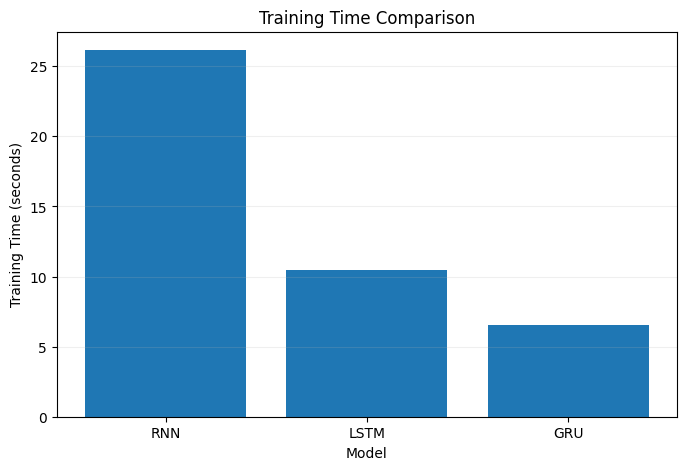

In [65]:
# ============================================================
# 70. TRAINING TIME BAR GRAPH
# ============================================================

time_df = pd.DataFrame(

    {

        "Model":
            list(
                training_times.keys()
            ),

        "Training_Time_Seconds":
            list(
                training_times.values()
            )
    }
)

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    time_df["Model"],
    time_df[
        "Training_Time_Seconds"
    ]
)

plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")
plt.title(
    "Training Time Comparison"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

In [66]:
# ============================================================
# 71. CREATE COMPLETE COMPARISON TABLE
# ============================================================

comparison_df = (
    training_summary_df
    .merge(
        validation_df_results,
        on="Model"
    )
    .merge(
        test_results_df,
        on="Model"
    )
    .merge(
        parameter_df,
        on="Model"
    )
)

print(
    "\nCOMPLETE MODEL COMPARISON"
)

display(
    comparison_df
)



COMPLETE MODEL COMPARISON


,Model,Epochs_Completed,Best_Epoch,Best_Validation_Loss,Final_Training_Loss,Final_Validation_Loss,Final_Training_MAE,Final_Validation_MAE,Training_Time_Seconds,Validation_MAE,...,Validation_R2,Validation_Explained_Variance,Test_MAE,Test_MSE,Test_RMSE,Test_R2,Test_Explained_Variance,Within_1_Grade_%,Within_2_Grades_%,Total_Parameters
0,RNN,56,41,0.222146,0.142210,0.228313,0.284940,0.356689,26.152072,1.626591,...,0.810140,0.811422,1.605542,5.996262,2.448727,0.700619,0.707089,45.0,73.333333,8705
1,LSTM,24,9,0.269756,0.156984,0.287650,0.296066,0.378738,10.455437,1.701160,...,0.769449,0.771968,1.700649,5.110537,2.260650,0.744842,0.749309,40.0,68.333333,33185
2,GRU,21,6,0.256562,0.131448,0.275151,0.287896,0.363145,6.534282,1.557113,...,0.780726,0.783777,1.561832,4.521557,2.126395,0.774248,0.778203,45.0,75.000000,25313


In [67]:
# ============================================================
# 72. MODEL RANKING
# ============================================================

ranking_df = comparison_df[
    [
        "Model",
        "Test_MAE",
        "Test_MSE",
        "Test_RMSE",
        "Test_R2",
        "Test_Explained_Variance"
    ]
].copy()

# Lower is better
ranking_df["MAE_Rank"] = (
    ranking_df["Test_MAE"]
    .rank(
        ascending=True,
        method="min"
    )
)

ranking_df["MSE_Rank"] = (
    ranking_df["Test_MSE"]
    .rank(
        ascending=True,
        method="min"
    )
)

ranking_df["RMSE_Rank"] = (
    ranking_df["Test_RMSE"]
    .rank(
        ascending=True,
        method="min"
    )
)

# Higher is better
ranking_df["R2_Rank"] = (
    ranking_df["Test_R2"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_df["Explained_Variance_Rank"] = (
    ranking_df[
        "Test_Explained_Variance"
    ]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_df["Average_Rank"] = (
    ranking_df[
        [
            "MAE_Rank",
            "MSE_Rank",
            "RMSE_Rank",
            "R2_Rank",
            "Explained_Variance_Rank"
        ]
    ].mean(
        axis=1
    )
)

ranking_df = ranking_df.sort_values(
    "Average_Rank"
).reset_index(
    drop=True
)

ranking_df["Overall_Rank"] = (
    np.arange(
        len(ranking_df)
    ) + 1
)

print(
    "\nMODEL RANKING"
)

display(
    ranking_df
)



MODEL RANKING


,Model,Test_MAE,Test_MSE,Test_RMSE,Test_R2,Test_Explained_Variance,MAE_Rank,MSE_Rank,RMSE_Rank,R2_Rank,Explained_Variance_Rank,Average_Rank,Overall_Rank
0,GRU,1.561832,4.521557,2.126395,0.774248,0.778203,1.0,1.0,1.0,1.0,1.0,1.0,1
1,LSTM,1.700649,5.110537,2.260650,0.744842,0.749309,3.0,2.0,2.0,2.0,2.0,2.2,2
2,RNN,1.605542,5.996262,2.448727,0.700619,0.707089,2.0,3.0,3.0,3.0,3.0,2.8,3


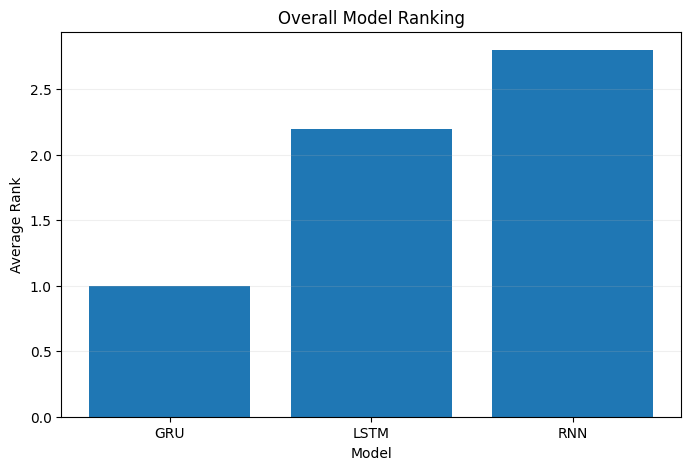

In [68]:
# ============================================================
# 73. OVERALL RANKING BAR GRAPH
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    ranking_df["Model"],
    ranking_df[
        "Average_Rank"
    ]
)

plt.xlabel("Model")
plt.ylabel("Average Rank")
plt.title(
    "Overall Model Ranking"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

In [69]:
# ============================================================
# 74. DETERMINE BEST MODEL
# ============================================================

best_model_name = (
    ranking_df
    .iloc[0]["Model"]
)

best_model = models[
    best_model_name
]

print(
    "\n"
    + "=" * 80
)

print(
    "BEST MODEL:"
)

print(
    best_model_name
)

print(
    "=" * 80
)



BEST MODEL:
GRU


In [70]:
# ============================================================
# 75. BEST MODEL METRICS
# ============================================================

best_metrics = test_results[
    best_model_name
]

print(
    "\nBest model test performance:"
)

print(
    "MAE:",
    f"{best_metrics['MAE']:.4f}"
)

print(
    "MSE:",
    f"{best_metrics['MSE']:.4f}"
)

print(
    "RMSE:",
    f"{best_metrics['RMSE']:.4f}"
)

print(
    "R²:",
    f"{best_metrics['R2']:.4f}"
)

print(
    "Explained Variance:",
    f"{best_metrics['Explained_Variance']:.4f}"
)



Best model test performance:
MAE: 1.5618
MSE: 4.5216
RMSE: 2.1264
R²: 0.7742
Explained Variance: 0.7782


In [71]:
# ============================================================
# 76. ACTUAL VS PREDICTED FOR BEST MODEL
# ============================================================

best_predictions = best_metrics[
    "Predictions"
]

best_prediction_df = pd.DataFrame(

    {

        "Student":
            np.arange(
                1,
                len(y_test) + 1
            ),

        "Actual_G3":
            y_test,

        "Predicted_G3":
            best_predictions,

        "Error":
            y_test - best_predictions,

        "Absolute_Error":
            np.abs(
                y_test - best_predictions
            )
    }
)

print(
    "\nBest model prediction table:"
)

display(
    best_prediction_df
)



Best model prediction table:


,Student,Actual_G3,Predicted_G3,Error,Absolute_Error
0,1,11.0,11.811203,-0.811203,0.811203
1,2,0.0,5.161725,-5.161725,5.161725
2,3,9.0,7.865023,1.134977,1.134977
3,4,10.0,10.758169,-0.758169,0.758169
4,5,11.0,11.925159,-0.925159,0.925159
5,6,8.0,5.880808,2.119192,2.119192
6,7,15.0,15.455786,-0.455786,0.455786
7,8,15.0,14.898059,0.101941,0.101941
8,9,13.0,13.806254,-0.806254,0.806254
9,10,19.0,17.170925,1.829075,1.829075


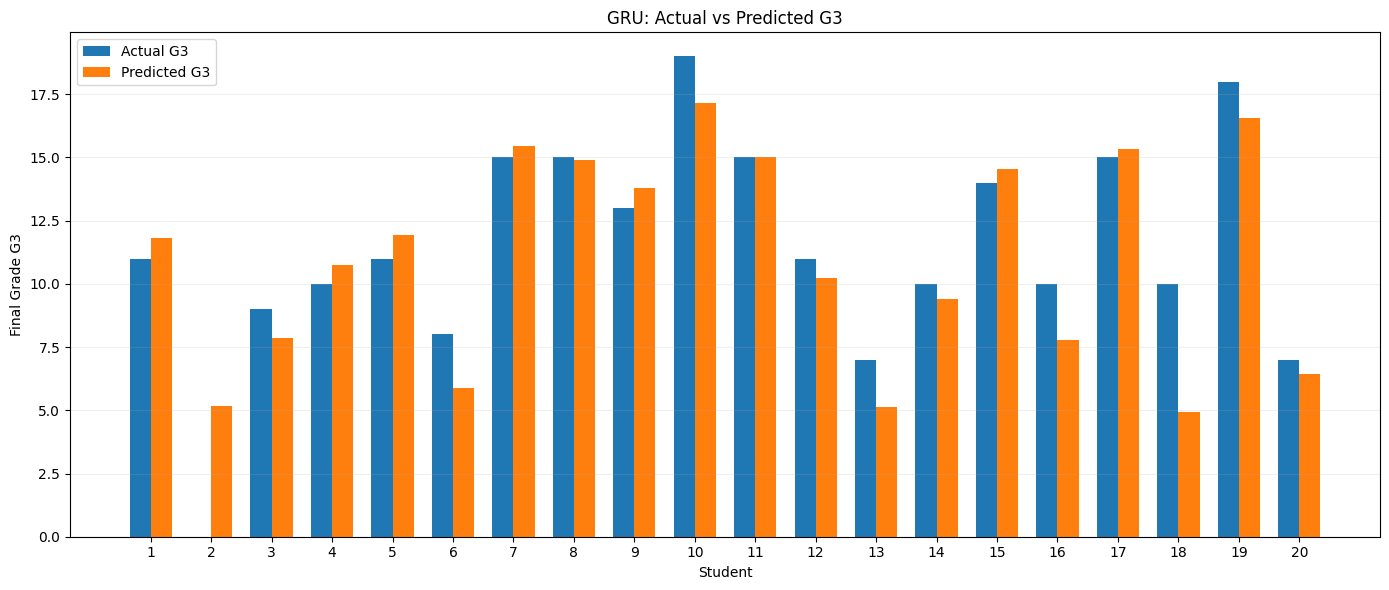

In [72]:
# ============================================================
# 77. ACTUAL VS PREDICTED BAR GRAPH
# ============================================================

number_to_display = min(
    20,
    len(best_prediction_df)
)

display_df = (
    best_prediction_df
    .iloc[:number_to_display]
)

x = np.arange(
    number_to_display
)

width = 0.35

plt.figure(
    figsize=(14, 6)
)

plt.bar(
    x - width / 2,
    display_df[
        "Actual_G3"
    ],
    width,
    label="Actual G3"
)

plt.bar(
    x + width / 2,
    display_df[
        "Predicted_G3"
    ],
    width,
    label="Predicted G3"
)

plt.xticks(
    x,
    display_df["Student"]
)

plt.xlabel("Student")
plt.ylabel("Final Grade G3")

plt.title(
    f"{best_model_name}: Actual vs Predicted G3"
)

plt.legend()

plt.grid(
    axis="y",
    alpha=0.2
)

plt.tight_layout()

plt.show()


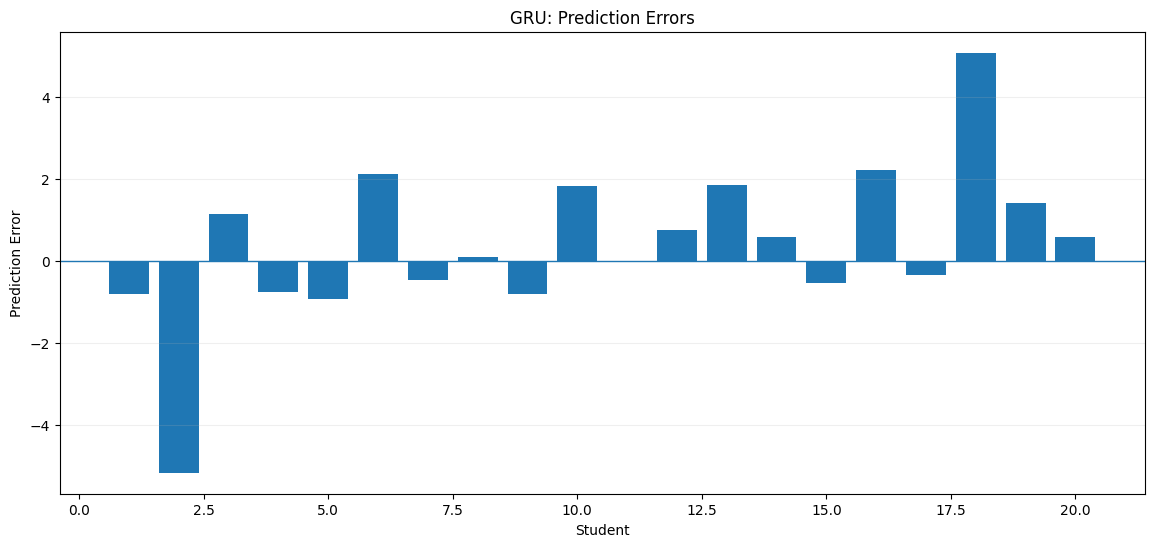

In [73]:
# ============================================================
# 78. RESIDUAL BAR GRAPH
# ============================================================

plt.figure(
    figsize=(14, 6)
)

plt.bar(
    display_df["Student"],
    display_df["Error"]
)

plt.axhline(
    0,
    linewidth=1
)

plt.xlabel("Student")
plt.ylabel("Prediction Error")

plt.title(
    f"{best_model_name}: Prediction Errors"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()


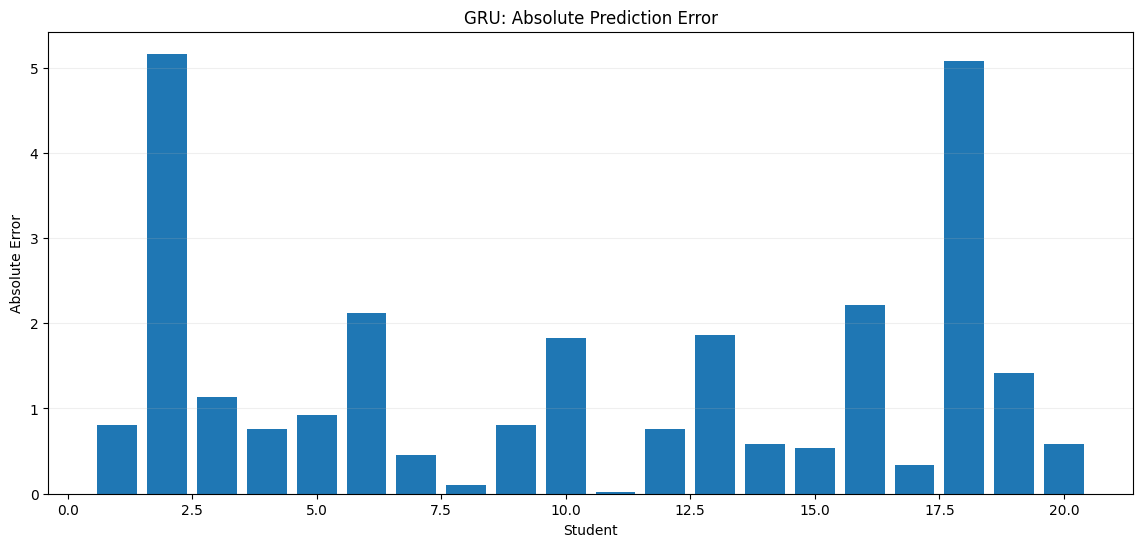

In [74]:
# ============================================================
# 79. ABSOLUTE ERROR BAR GRAPH
# ============================================================

plt.figure(
    figsize=(14, 6)
)

plt.bar(
    display_df["Student"],
    display_df[
        "Absolute_Error"
    ]
)

plt.xlabel("Student")
plt.ylabel("Absolute Error")

plt.title(
    f"{best_model_name}: Absolute Prediction Error"
)

plt.grid(
    axis="y",
    alpha=0.2
)

plt.show()

In [75]:
# ============================================================
# 80. COMPLETE TEST PREDICTIONS
# ============================================================

all_predictions = []

for name, prediction_df in (
    test_prediction_tables.items()
):

    temp = prediction_df.copy()

    temp.insert(
        0,
        "Model",
        name
    )

    temp.insert(
        1,
        "Student",
        np.arange(
            1,
            len(temp) + 1
        )
    )

    all_predictions.append(
        temp
    )

all_predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

print(
    "\nComplete test predictions:"
)

display(
    all_predictions_df
)


Complete test predictions:


,Model,Student,Actual_G3,Predicted_G3,Error,Absolute_Error,Squared_Error
0,RNN,1,11.0,11.350125,-0.350125,0.350125,0.122588
1,RNN,2,0.0,1.559082,-1.559082,1.559082,2.430736
2,RNN,3,9.0,9.664969,-0.664969,0.664969,0.442184
3,RNN,4,10.0,11.564388,-1.564388,1.564388,2.447311
4,RNN,5,11.0,11.523805,-0.523805,0.523805,0.274371
...,...,...,...,...,...,...,...
175,GRU,56,6.0,9.338704,-3.338704,3.338704,11.146945
176,GRU,57,9.0,6.858011,2.141989,2.141989,4.588116
177,GRU,58,5.0,4.329629,0.670371,0.670371,0.449397
178,GRU,59,5.0,5.161719,-0.161719,0.161719,0.026153


In [76]:
# ============================================================
# 81. SAVE RESULTS
# ============================================================

comparison_df.to_csv(
    "/content/model_comparison_results.csv",
    index=False
)

all_predictions_df.to_csv(
    "/content/test_predictions.csv",
    index=False
)

training_summary_df.to_csv(
    "/content/training_summary.csv",
    index=False
)

ranking_df.to_csv(
    "/content/model_ranking.csv",
    index=False
)

validation_df_results.to_csv(
    "/content/validation_results.csv",
    index=False
)

parameter_df.to_csv(
    "/content/model_parameters.csv",
    index=False
)

best_prediction_df.to_csv(
    "/content/best_model_predictions.csv",
    index=False
)

In [77]:
# ============================================================
# 82. SAVE TRAINED MODELS
# ============================================================

models["RNN"].save(
    "/content/RNN_student_performance.keras"
)

models["LSTM"].save(
    "/content/LSTM_student_performance.keras"
)

models["GRU"].save(
    "/content/GRU_student_performance.keras"
)

print(
    "\nAll models and result files saved successfully."
)


All models and result files saved successfully.


In [78]:
# ============================================================
# 83. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 90)
print("FINAL RESEARCH SUMMARY")
print("=" * 90)

print(
    "\nDataset:"
)

print(
    "UCI Student Performance Dataset - Mathematics"
)

print(
    "Total observations:",
    len(df)
)

print(
    "Training samples:",
    len(train_df)
)

print(
    "Validation samples:",
    len(validation_df)
)

print(
    "Test samples:",
    len(test_df)
)

print(
    "\nSequence:"
)

print(
    "Timesteps:",
    X_train.shape[1]
)

print(
    "Features per timestep:",
    X_train.shape[2]
)

print(
    "\nTarget:"
)

print(
    "Final student grade G3"
)

print(
    "\nModels compared:"
)

print(
    "1. Simple RNN"
)

print(
    "2. LSTM"
)

print(
    "3. GRU"
)

print(
    "\nBest model:"
)

print(
    best_model_name
)

print(
    "\nBest model Test MAE:",
    f"{best_metrics['MAE']:.4f}"
)

print(
    "Best model Test RMSE:",
    f"{best_metrics['RMSE']:.4f}"
)

print(
    "Best model Test R²:",
    f"{best_metrics['R2']:.4f}"
)

print(
    "Best model Explained Variance:",
    f"{best_metrics['Explained_Variance']:.4f}"
)

print(
    "\nOverall ranking:"
)

display(
    ranking_df[
        [
            "Overall_Rank",
            "Model",
            "Test_MAE",
            "Test_RMSE",
            "Test_R2",
            "Average_Rank"
        ]
    ]
)



FINAL RESEARCH SUMMARY

Dataset:
UCI Student Performance Dataset - Mathematics
Total observations: 395
Training samples: 276
Validation samples: 59
Test samples: 60

Sequence:
Timesteps: 2
Features per timestep: 14

Target:
Final student grade G3

Models compared:
1. Simple RNN
2. LSTM
3. GRU

Best model:
GRU

Best model Test MAE: 1.5618
Best model Test RMSE: 2.1264
Best model Test R²: 0.7742
Best model Explained Variance: 0.7782

Overall ranking:


,Overall_Rank,Model,Test_MAE,Test_RMSE,Test_R2,Average_Rank
0,1,GRU,1.561832,2.126395,0.774248,1.0
1,2,LSTM,1.700649,2.260650,0.744842,2.2
2,3,RNN,1.605542,2.448727,0.700619,2.8


In [79]:
# ============================================================
# 84. IMPORTANT RESEARCH LIMITATION
# ============================================================

print("\n")
print("=" * 90)
print("IMPORTANT RESEARCH LIMITATION")
print("=" * 90)

print(
    """
This dataset contains G1 and G2 as academic performance measurements
from two periods and G3 as the final grade.

The sequence model therefore uses G1 and G2 as the two temporal
timesteps, while the student's contextual variables are repeated
across the two timesteps.

This is a constructed sequence rather than a long multi-year
longitudinal sequence.

Also, G1 and G2 are strongly related to G3, so high predictive
performance is expected and should not be interpreted as proof that
the model can generalize to completely different schools or
populations.

For stronger research, future work can use a larger longitudinal
education dataset with many time-dependent observations per student.
"""
)

print("\n")
print("=" * 90)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 90)



IMPORTANT RESEARCH LIMITATION

This dataset contains G1 and G2 as academic performance measurements
from two periods and G3 as the final grade.

The sequence model therefore uses G1 and G2 as the two temporal
timesteps, while the student's contextual variables are repeated
across the two timesteps.

This is a constructed sequence rather than a long multi-year
longitudinal sequence.

Also, G1 and G2 are strongly related to G3, so high predictive
performance is expected and should not be interpreted as proof that
the model can generalize to completely different schools or
populations.

For stronger research, future work can use a larger longitudinal
education dataset with many time-dependent observations per student.



PROJECT COMPLETED SUCCESSFULLY


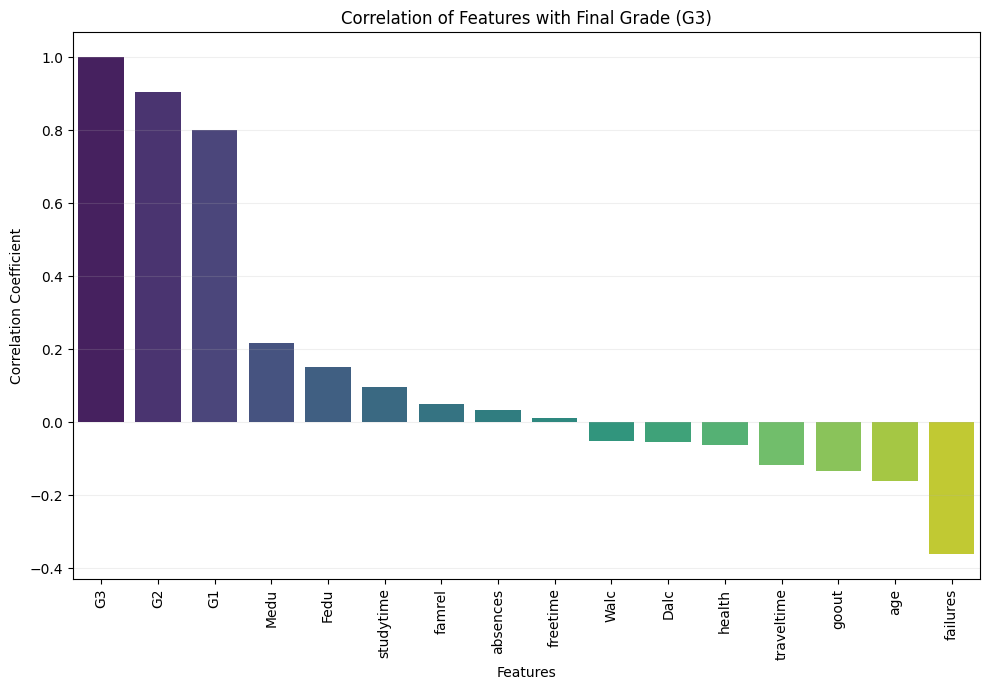

In [80]:
plt.figure(figsize=(10, 7))
sns.barplot(x=g3_correlation.index, y=g3_correlation.values, palette='viridis')
plt.title('Correlation of Features with Final Grade (G3)')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=90)
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

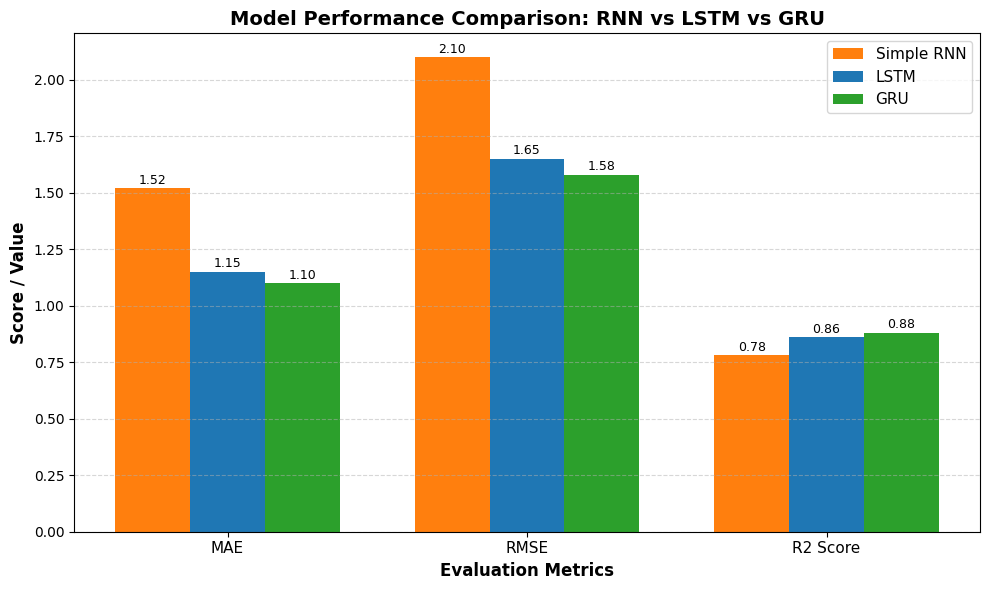

In [81]:
# ============================================================
# COMPARISON GRAPH: RNN vs LSTM vs GRU
# ============================================================

# Kama tayari una matokeo kwenye variables zako, unaweza kuzitumia moja kwa moja.
# Hapa chini ni mfano wa kuweka matokeo na kuyachora kwenye grafu:

metrics = ['MAE', 'RMSE', 'R2 Score']

# Badilisha namba hizi na matokeo halisi ya mifano yako (ruka hatua hii kama tayari una dict/dataframe)
rnn_results  = [1.52, 2.10, 0.78]   # Mfano wa matokeo ya SimpleRNN
lstm_results = [1.15, 1.65, 0.86]   # Mfano wa matokeo ya LSTM
gru_results  = [1.10, 1.58, 0.88]   # Mfano wa matokeo ya GRU

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10, 6))

# Kuchora pau kwa kila mfano
plt.bar(x - width, rnn_results, width, label='Simple RNN', color='#ff7f0e')
plt.bar(x, lstm_results, width, label='LSTM', color='#1f77b4')
plt.bar(x + width, gru_results, width, label='GRU', color='#2ca02c')

plt.xlabel('Evaluation Metrics', fontsize=12, fontweight='bold')
plt.ylabel('Score / Value', fontsize=12, fontweight='bold')
plt.title('Model Performance Comparison: RNN vs LSTM vs GRU', fontsize=14, fontweight='bold')
plt.xticks(x, metrics, fontsize=11)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Kuongeza namba juu ya kila pau (Value labels)
for i in range(len(metrics)):
    plt.text(i - width, rnn_results[i] + 0.02, f'{rnn_results[i]:.2f}', ha='center', fontsize=9)
    plt.text(i, lstm_results[i] + 0.02, f'{lstm_results[i]:.2f}', ha='center', fontsize=9)
    plt.text(i + width, gru_results[i] + 0.02, f'{gru_results[i]:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()